<a href="https://colab.research.google.com/github/FinancialWisdomAI/FinancialWisdomSimulator/blob/main/financial_wisdom_simulator_V2C_Goal_Optimization_Validated_Display_Enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Asset database loaded.

                         Asset  MeanReturn  StdDev
0           S&P 500 Index Fund      0.1185   0.194
1   60/40 Stock-Bond Portfolio      0.0800   0.120
2       Conservative Portfolio      0.0500   0.060
3                 US Large Cap      0.1185   0.194
4                 US Small Cap      0.1200   0.250
5         International Stocks      0.0850   0.170
6                        Bonds      0.0500   0.070
7                         Cash      0.0250   0.010
8                        REITs      0.1000   0.200
9                Growth Stocks      0.1300   0.230
10                Value Stocks      0.1100   0.180
11              Treasury Bonds      0.0400   0.050
12                        Gold      0.0600   0.150
Historical model loaded.
Return matrix shape: (118, 11)
Covariance matrix shape: (11, 11)
 Financial Wisdom Monte Carlo Simulator

What is your financial goal? retire
What is your goal amount ($)? 1000000
How many years until you need the money? 20
Initial inve

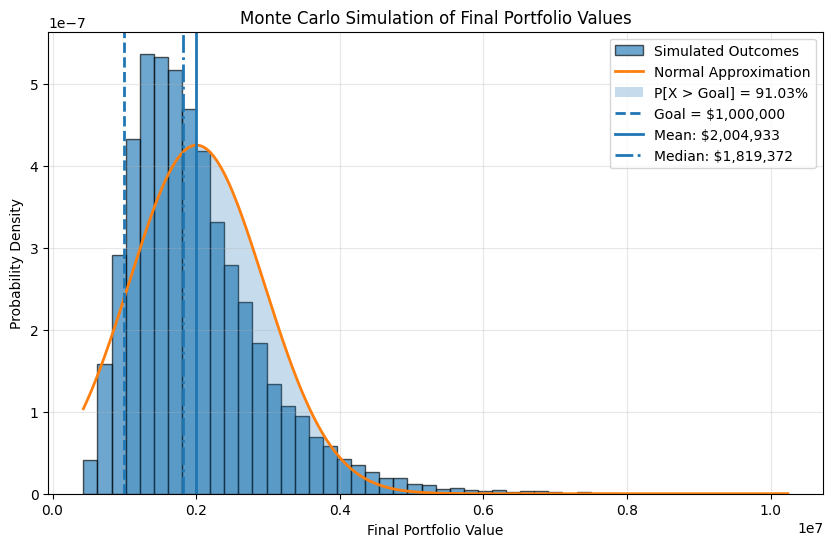

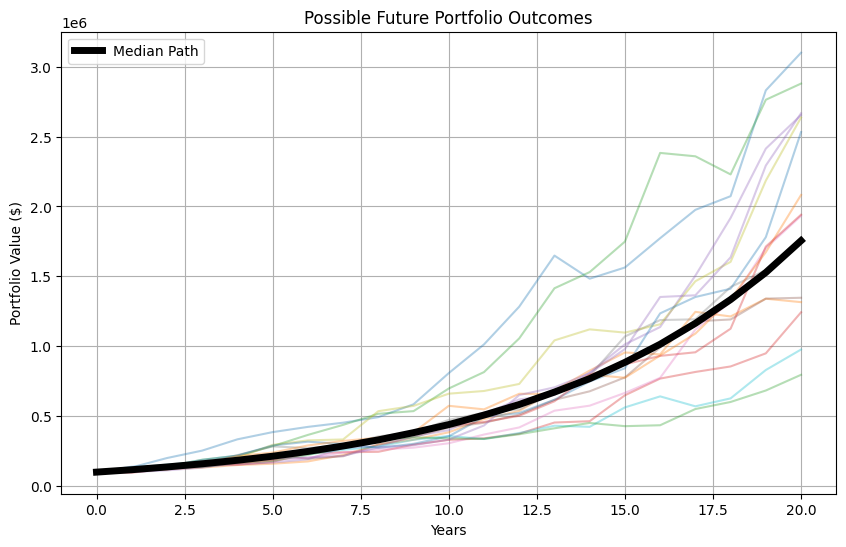


 Hidden Risk Structure

Dominant common market movement: 79.7%
Gold-related movement: 12.9%
Growth vs. value / real-asset movement: 6.1%
Other independent movements: 1.4%

The first three movement patterns explain 98.6%
of the historical variance in this portfolio.

What do I know?
About 79.7% of this portfolio's historical variance
is associated with one dominant pattern of market movement.

What does it mean?
Several investments may have different names
but still respond to some of the same underlying market forces.
Other investments participate in different movement patterns.
Those differences can help reduce dependence on a single source
of market movement.

Financial Wisdom:
Diversification is not simply owning more investments.
It comes from combining investments that do not all behave
the same way under changing market conditions.

Historical relationships can change.
PCA describes the data we observed; it does not predict
future market behavior.


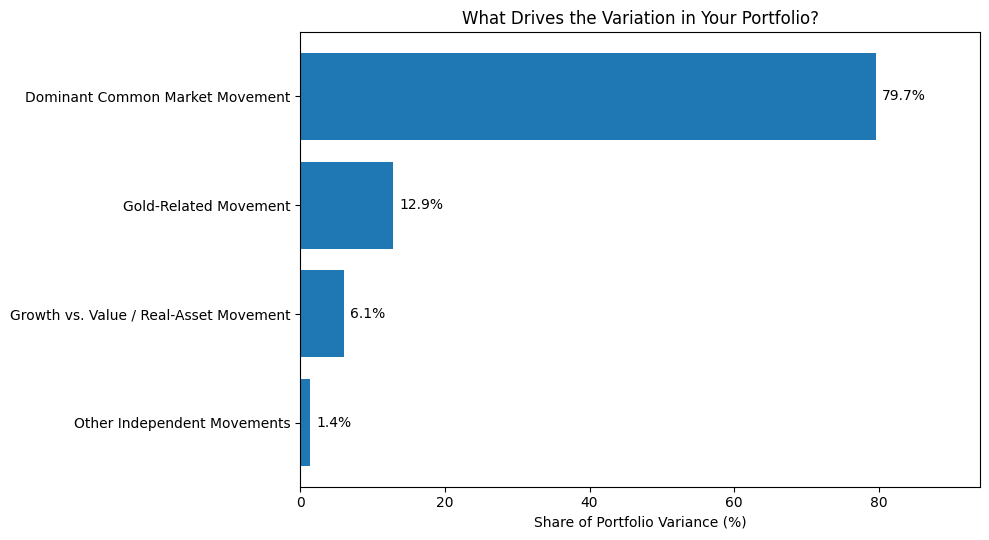

In [38]:
# ============================================================
# FINANCIAL WISDOM MONTE CARLO SIMULATOR
# Basic single-cell notebook version for Colab debugging
# ============================================================


# --------------------------- config.py ---------------------------
"""Configuration values for the Financial Wisdom Simulator."""

DEFAULT_NUM_SIMULATIONS = 10_000
RANDOM_SEED = 42
MIN_ANNUAL_RETURN = -0.99

# --------------------------- user_inputs.py ---------------------------
"""User input and validation helpers."""
import sys
import yfinance as yf
from scipy.optimize import minimize


def _quit_if_requested(response: str) -> None:
    if response.lower() in ["q", "quit", "exit"]:
        print("\nExiting Financial Wisdom Simulator.")
        sys.exit()

def get_money(prompt: str, min_value=None, allow_zero=True) -> float:
    while True:
        response = input(prompt).strip()
        _quit_if_requested(response)
        try:
            value = float(response.replace('$', '').replace(',', ''))

            if min_value is not None and value < min_value:
                  print(f"Please enter an amount of at least ${min_value:,.0f}.")
                  continue

            if not allow_zero and value == 0:
                  print("Please enter an amount greater than $0.")
                  continue

            return value
        except ValueError:
            print("Please enter a valid dollar amount. Examples: 1000, 1,000, $1,000. Type 'q' to quit.")

def get_integer(prompt: str,min_value=None,max_value=None,allow_zero=True) -> int:
    while True:
        response = input(prompt).strip()
        _quit_if_requested(response)

        try:
            value = int(response.replace('$', '').replace(',', ''))

            if min_value is not None and value < min_value:
                print(f"Please enter a value of at least {min_value}.")
                continue

            if max_value is not None and value > max_value:
                print(f"Please enter a value no greater than {max_value}.")
                continue

            if not allow_zero and value == 0:
                print("Please enter a value greater than 0.")
                continue

            return value

        except ValueError:
            print("Please enter a whole number. Examples: 10000 or 10,000. Type 'q' to quit.")

def get_float(prompt, min_value=None, max_value=None,default=None):
    while True:
        try:
            response = input(prompt).strip()
            _quit_if_requested(response)


            if response == "" and default is not None:
                return default

            value = float(response)

            if min_value is not None and value < min_value:
                print(
                    f"Please enter a value of at least "
                    f"{min_value}."
                )
                continue

            if max_value is not None and value > max_value:
                print(
                    f"Please enter a value no greater than "
                    f"{max_value}."
                )
                continue

            return value

        except ValueError:
            print("Please enter a valid number.")


def get_yes_no(prompt: str) -> str:
    while True:
        response = input(prompt).strip().lower()
        _quit_if_requested(response)
        if response in ["yes", "y"]:
            return "Yes"
        if response in ["no", "n"]:
            return "No"
        print("Please answer Yes or No. Examples: yes, y, no, n. Type 'q' to quit.")


def collect_user_plan() -> dict:
    print("=====================================")
    print(" Financial Wisdom Monte Carlo Simulator")
    print("======================================\n")

    plan = {}

    response = input(
       "What is your financial goal? "
    ).strip()
    _quit_if_requested(response)
    plan["goal_name"] = response

    plan["goal_amount"] = get_money(
       "What is your goal amount ($)? ",
       min_value=0,
       allow_zero=False
    )

    plan["years"] = get_integer(
       "How many years until you need the money? ",
       min_value=1
    )

    plan["initial_balance"] = get_money(
       "Initial investment amount ($): ",
       min_value=0
    )

    if plan["initial_balance"] >= plan["goal_amount"]:
       print("\nYour initial investment already meets or exceeds your stated goal.")
       print(f"Goal Amount: ${plan['goal_amount']:,.2f}")
       print(f"Initial Investment: ${plan['initial_balance']:,.2f}")
       print("\nPlease check your entries before continuing.")

    plan["monthly_contribution"] = get_money(
       "Monthly contribution ($): ",
       min_value=0
    )

    return plan

# -------------------------------- portfolio.py --------------------------------
"""Asset database and portfolio construction."""
import pandas as pd

ASSET_DATA = [
    {"Asset": "S&P 500 Index Fund", "MeanReturn": 0.1185, "StdDev": 0.194},
    {"Asset": "60/40 Stock-Bond Portfolio", "MeanReturn": 0.0800, "StdDev": 0.120},
    {"Asset": "Conservative Portfolio", "MeanReturn": 0.0500, "StdDev": 0.060},
    {"Asset": "US Large Cap", "MeanReturn": 0.1185, "StdDev": 0.194},
    {"Asset": "US Small Cap", "MeanReturn": 0.1200, "StdDev": 0.250},
    {"Asset": "International Stocks", "MeanReturn": 0.0850, "StdDev": 0.170},
    {"Asset": "Bonds", "MeanReturn": 0.0500, "StdDev": 0.070},
    {"Asset": "Cash", "MeanReturn": 0.0250, "StdDev": 0.010},
    {"Asset": "REITs", "MeanReturn": 0.1000, "StdDev": 0.200},
    {"Asset": "Growth Stocks", "MeanReturn": 0.1300, "StdDev": 0.230},
    {"Asset": "Value Stocks", "MeanReturn": 0.1100, "StdDev": 0.180},
    {"Asset": "Treasury Bonds", "MeanReturn": 0.0400, "StdDev": 0.050},
    {"Asset": "Gold", "MeanReturn": 0.0600, "StdDev": 0.150},
]

# ============================================================
# HISTORICAL DATA ENGINE
# Historical ETF proxies for simulator asset classes
# ============================================================

ASSET_PROXIES = {
    "S&P 500 Index Fund": "VOO",
    "US Large Cap": "VOO",
    "US Small Cap": "VB",
    "International Stocks": "VXUS",
    "Bonds": "BND",
    "Cash": "BIL",
    "REITs": "VNQ",
    "Growth Stocks": "VUG",
    "Value Stocks": "VTV",
    "Treasury Bonds": "IEF",
    "Gold": "GLD",
}

def calculate_returns(prices):
    returns = prices.pct_change()
    return returns.dropna()

def calculate_statistics(returns):
    mean_returns = returns.mean()
    std_returns = returns.std()
    correlation_matrix = returns.corr()
    covariance_matrix = returns.cov()

    return (
        mean_returns,
        std_returns,
        correlation_matrix,
        covariance_matrix
    )


def calculate_portfolio_statistics(
    weights,
    mean_returns,
    covariance_matrix
):

    weights = pd.Series(weights, dtype=float)
    selected_assets = weights.index

    missing_assets = [
        asset for asset in selected_assets
        if asset not in covariance_matrix.columns
    ]

    if missing_assets:
        raise ValueError(
            f"Historical data missing for: {missing_assets}"
        )

    if not np.isclose(weights.sum(), 1.0):
        raise ValueError(
            "Portfolio weights must sum to 1.0."
        )

    means = mean_returns.reindex(selected_assets)

    cov = covariance_matrix.reindex(
        index=selected_assets,
        columns=selected_assets
    )

    portfolio_return = weights @ means

    portfolio_variance = (
        weights.values.T
        @ cov.values
        @ weights.values
    )

    portfolio_std = np.sqrt(
        portfolio_variance
    )

    return (
        portfolio_return,
        portfolio_variance,
        portfolio_std
    )

def calculate_annual_portfolio_inputs(
    weights,
    mean_returns,
    covariance_matrix
):

    (
        monthly_return,
        monthly_variance,
        monthly_std
    ) = calculate_portfolio_statistics(
        weights,
        mean_returns,
        covariance_matrix
    )

    annual_return = (
        (1 + monthly_return) ** 12 - 1
    )

    annual_std = (
        monthly_std * np.sqrt(12)
    )

    return annual_return, annual_std


def download_historical_data():

    tickers = sorted(set(ASSET_PROXIES.values()))

    data = yf.download(
        tickers,
        period="10y",
        interval="1mo",
        auto_adjust=True,
        progress=False
    )

    prices = data["Close"].copy()

    # Remove incomplete current month
    today = pd.Timestamp.today()
    current_month_start = (
        today.to_period("M").to_timestamp()
    )

    prices = prices[
        prices.index < current_month_start
    ].copy()

    return prices


def build_historical_model():

    prices = download_historical_data()

    returns = calculate_returns(prices)

    asset_returns = pd.DataFrame(
        index=returns.index
    )

    for asset_name, ticker in ASSET_PROXIES.items():
        asset_returns[asset_name] = returns[ticker]

    (
        mean_returns,
        std_returns,
        correlation_matrix,
        covariance_matrix
    ) = calculate_statistics(asset_returns)

    return (
        asset_returns,
        mean_returns,
        std_returns,
        correlation_matrix,
        covariance_matrix
    )


def load_asset_database() -> pd.DataFrame:
    return pd.DataFrame(ASSET_DATA)


def evaluate_frontier_goal_probabilities(
    frontier,
    initial_balance,
    monthly_contribution,
    years,
    goal_amount,
    num_simulations=10000,
    random_seed=42
    ):

    evaluated_frontier = frontier.copy()

    goal_probabilities = []

    for _, row in evaluated_frontier.iterrows():

        final_values = simulate_portfolio(
            initial_balance=initial_balance,
            monthly_contribution=monthly_contribution,
            years=years,
            mean_return=row["Annual Return"],
            std_return=row["Annual Risk"],
            num_simulations=num_simulations,
            random_seed=random_seed
        )

        probability = np.mean(
            final_values >= goal_amount
        )

        goal_probabilities.append(probability)

    evaluated_frontier[
        "Goal Probability"
    ] = goal_probabilities

    return evaluated_frontier

def select_goal_based_portfolio(
    frontier,
    desired_success_probability
    ):

    eligible = frontier[
        frontier["Goal Probability"]
        >= desired_success_probability
    ]

    if eligible.empty:
        return None

    selected = eligible.loc[
        eligible["Annual Risk"].idxmin()
    ]

    return selected


def optimize_goal_based_portfolio(
    mean_returns,
    covariance_matrix,
    initial_balance,
    monthly_contribution,
    years,
    goal_amount,
    desired_success_probability=0.90,
    concentration_limit=0.35,
    num_frontier_portfolios=50,
    num_simulations=10000,
    random_seed=42
    ):

    frontier = build_constrained_frontier(
        mean_returns,
        covariance_matrix,
        concentration_limit=concentration_limit,
        num_portfolios=num_frontier_portfolios
    )

    frontier = evaluate_frontier_goal_probabilities(
        frontier,
        initial_balance=initial_balance,
        monthly_contribution=monthly_contribution,
        years=years,
        goal_amount=goal_amount,
        num_simulations=num_simulations,
        random_seed=random_seed
    )

    selected = select_goal_based_portfolio(
        frontier,
        desired_success_probability
    )

    return selected, frontier



from scipy.optimize import minimize


def portfolio_variance(
    weights,
    covariance_matrix
):
    return (
        weights.T
        @ covariance_matrix.values
        @ weights
    )


def optimize_for_target_return(
    target_annual_return,
    mean_returns,
    covariance_matrix,
    initial_weights=None,
    bounds=None
    ):

    num_assets = len(mean_returns)

    target_monthly_return = (
        (1 + target_annual_return) ** (1 / 12) - 1
    )

    if initial_weights is None:
        initial_weights = (
            np.ones(num_assets) / num_assets
        )

    if bounds is None:
        bounds = [
            (0.0, 1.0)
            for _ in range(num_assets)
        ]

    constraints = [
        {
            "type": "eq",
            "fun": lambda weights:
                np.sum(weights) - 1
        },
        {
            "type": "eq",
            "fun": lambda weights:
                weights @ mean_returns.values
                - target_monthly_return
        }
    ]

    result = minimize(
        portfolio_variance,
        initial_weights,
        args=(covariance_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "ftol": 1e-12,
            "maxiter": 1000
        }
    )

    return result





def build_constrained_frontier(
    mean_returns,
    covariance_matrix,
    concentration_limit=0.35,
    num_portfolios=50
):
    num_assets = len(mean_returns)

    initial_weights = (
        np.ones(num_assets) / num_assets
    )

    bounds = [
        (0.0, concentration_limit)
        for _ in range(num_assets)
    ]

    sum_constraint = {
        "type": "eq",
        "fun": lambda weights:
            np.sum(weights) - 1
    }

    # Find constrained minimum-variance portfolio
    min_result = minimize(
        portfolio_variance,
        initial_weights,
        args=(covariance_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=sum_constraint,
        options={
            "ftol": 1e-12,
            "maxiter": 1000
        }
    )

    if not min_result.success:
        raise ValueError(
            "Minimum-variance optimization failed."
        )

    min_weights = min_result.x

    min_monthly_return = (
        min_weights @ mean_returns.values
    )

    min_annual_return = (
        (1 + min_monthly_return) ** 12 - 1
    )

    max_annual_return = (
        (1 + mean_returns.max()) ** 12 - 1
    )

    target_returns = np.linspace(
        min_annual_return,
        max_annual_return,
        num_portfolios
    )

    frontier_results = []

    starting_weights = min_weights.copy()

    for target_return in target_returns:

        result = optimize_for_target_return(
            target_return,
            mean_returns,
            covariance_matrix,
            initial_weights=starting_weights,
            bounds=bounds
        )

        if not result.success:
            continue

        weights = result.x

        monthly_return = (
            weights @ mean_returns.values
        )

        monthly_variance = (
            weights.T
            @ covariance_matrix.values
            @ weights
        )

        annual_return = (
            (1 + monthly_return) ** 12 - 1
        )

        annual_risk = (
            np.sqrt(monthly_variance)
            * np.sqrt(12)
        )

        frontier_results.append(
            {
                "Annual Return": annual_return,
                "Annual Risk": annual_risk,
                "Weights": weights.copy()
            }
        )

        starting_weights = weights.copy()

    return pd.DataFrame(frontier_results)

def optimize_goal_based_portfolio(
    mean_returns,
    covariance_matrix,
    initial_balance,
    monthly_contribution,
    years,
    goal_amount,
    desired_success_probability=0.90,
    concentration_limit=0.35,
    num_frontier_portfolios=50,
    num_simulations=10000,
    random_seed=42
):
    frontier = build_constrained_frontier(
        mean_returns,
        covariance_matrix,
        concentration_limit=concentration_limit,
        num_portfolios=num_frontier_portfolios
    )

    frontier = evaluate_frontier_goal_probabilities(
        frontier,
        initial_balance=initial_balance,
        monthly_contribution=monthly_contribution,
        years=years,
        goal_amount=goal_amount,
        num_simulations=num_simulations,
        random_seed=random_seed
    )

    selected = select_goal_based_portfolio(
        frontier,
        desired_success_probability
    )

    return selected, frontier


def choose_portfolio(
    asset_db: pd.DataFrame,
    asset_mean_returns: pd.Series,
    asset_covariance_matrix: pd.DataFrame,
    plan: dict
    ) -> dict:

    print("\nPortfolio Construction Method")
    print("1 - Predefined Portfolio")
    print("2 - Build Custom Portfolio")
    print("3 - Goal-Based Optimized Portfolio")

    portfolio_method = get_integer(
        "Choose method (1-3): ",
        min_value=1,
        max_value=3
    )

    # -------------------------------------------------
    # PREDEFINED PORTFOLIO
    # Keep existing assumptions for now
    # -------------------------------------------------

    if portfolio_method == 1:

        print("\nPredefined Portfolios")
        print("1 - S&P 500 Index Fund")
        print("2 - 60/40 Stock-Bond Portfolio")
        print("3 - Conservative Portfolio")

        portfolio_choice = get_integer(
            "Choose portfolio (1-3): ",
            min_value=1,
            max_value=3
        )

        row = asset_db.iloc[
            portfolio_choice - 1
        ]

        return {
            "portfolio_method": portfolio_method,
            "portfolio_choice": portfolio_choice,
            "portfolio_name": row["Asset"],
            "mean_return": float(
                row["MeanReturn"]
            ),
            "std_return": float(
                row["StdDev"]
            ),
            "weights": None,
        }


    if portfolio_method == 3:

        risk_limits = {
            1: 0.08,
            2: 0.12,
            3: 0.18
        }

        risk_limit = risk_limits[
            plan["risk_tolerance"]
        ]

        optimization_assets = [
            "S&P 500 Index Fund",
            "US Small Cap",
            "International Stocks",
            "Bonds",
            "Cash",
            "REITs",
            "Growth Stocks",
            "Value Stocks",
            "Treasury Bonds",
            "Gold",
        ]

        optimization_mean_returns = asset_mean_returns.reindex(
            optimization_assets
        )

        optimization_covariance_matrix = asset_covariance_matrix.reindex(
            index=optimization_assets,
            columns=optimization_assets
        )

        optimized_portfolio, optimized_frontier = (
            optimize_goal_based_portfolio(
                optimization_mean_returns,
                optimization_covariance_matrix,
                initial_balance=plan["initial_balance"],
                monthly_contribution=plan["monthly_contribution"],
                years=plan["years"],
                goal_amount=plan["goal_amount"],
                desired_success_probability=0.90,
                concentration_limit=0.35,
                num_frontier_portfolios=50,
                num_simulations=plan["num_simulations"],
                random_seed=RANDOM_SEED
            )
        )

        optimized_frontier = optimized_frontier[
            optimized_frontier["Annual Risk"]
            <= risk_limit
        ].copy()

        optimized_portfolio = select_goal_based_portfolio(
            optimized_frontier,
            0.90
        )

        if optimized_portfolio is None:

            return {
                "portfolio_method": 3,
                "portfolio_choice": None,
                "portfolio_name": "No Feasible Goal-Based Portfolio",
                "optimization_failed": True,
                "reason": (
                    "No portfolio reached the required "
                    "90% success probability."
                ),
            }

        weights = dict(
            zip(
                optimization_mean_returns.index,
                optimized_portfolio["Weights"]
            )
        )

        return {
            "portfolio_method": portfolio_method,
            "portfolio_choice": None,
            "portfolio_name": "Goal-Based Optimized Portfolio",
            "mean_return": float(
             optimized_portfolio["Annual Return"]
            ),
            "std_return": float(
                optimized_portfolio["Annual Risk"]
            ),
            "weights": weights,
            "goal_probability": float(
                optimized_portfolio["Goal Probability"]
            ),
        }


    # -------------------------------------------------
    # CUSTOM PORTFOLIO
    # Use only assets with historical data
    # -------------------------------------------------

    custom_assets = list(
        asset_mean_returns.index
    )

    weights = {}
    running_total = 0

    for asset in custom_assets:
        while True:
            print(
                f"\nCurrent portfolio allocation: "
                f"{running_total}%"
            )

            pct = get_integer(
                f"Allocation to {asset} (%): "
            )

            if pct == -1:
                print("\nPortfolio construction cancelled.")
                return None

            if pct < 0:
                print(
                    "Allocation cannot be negative. "
                    "Please enter the percentage again."
                )
                continue

            if running_total + pct > 100:
                remaining = 100 - running_total
                print(
                    f"\nAllocation would total: "
                    f"{running_total + pct}%"
                )
                print(
                    "Portfolio allocation cannot exceed 100%."
                )
                print(
                    f"Enter a new allocation for {asset} "
                    f"or -1 to exit."
                )
                continue

            if pct > 0:
                weights[asset] = pct / 100.0

            running_total += pct

            print(
                f"Current portfolio allocation: "
                f"{running_total}%"
            )

            break

    total_weight = sum(weights.values())

    if not np.isclose(
        total_weight,
        1.0
    ):
        raise ValueError(
            f"Allocations must total 100%. "
            f"Current total = "
            f"{total_weight:.2%}"
        )

    # -------------------------------------------------
    # Historical covariance-based portfolio statistics
    # -------------------------------------------------

    mean_return, std_return = (
        calculate_annual_portfolio_inputs(
            weights,
            asset_mean_returns,
            asset_covariance_matrix
        )
    )

    return {
        "portfolio_method": portfolio_method,
        "portfolio_choice": None,
        "portfolio_name": "Custom Portfolio",
        "mean_return": float(
            mean_return
        ),
        "std_return": float(
            std_return
        ),
        "weights": weights,
    }

def display_portfolio_statistics(portfolio: dict) -> None:

    print("\n======================================")
    print(" Portfolio Statistics")
    print("=====================================")

    print(f"Portfolio: {portfolio['portfolio_name']}")
    print(f"Expected Return: {portfolio['mean_return']:.2%}")
    print(f"Estimated Risk : {portfolio['std_return']:.2%}")

    # Display allocation for goal-based optimized portfolio
    if portfolio["portfolio_method"] == 3:

        print("\nRecommended Asset Allocation")

        for asset, weight in portfolio["weights"].items():
            if weight > 0.001:
                print(f"{asset:25s} {weight:7.2%}")

        print("\nWhy this portfolio?")

        print(
            "This is the lowest-risk portfolio found that achieved "
            "at least"
        )

        print(
            "a 90% simulated probability of reaching your "
            "financial goal."
        )


# --------------------------- monte_carlo.py ---------------------------
"""Monte Carlo simulation engine."""
import numpy as np


def simulate_portfolio(initial_balance: float, monthly_contribution: float, years: int,
                       mean_return: float, std_return: float, num_simulations: int,
                       min_annual_return: float = -0.99, random_seed=None) -> np.ndarray:
    rng = np.random.default_rng(random_seed)
    final_values = []

    for _ in range(num_simulations):
        balance = initial_balance
        for _ in range(years):
            annual_return = max(rng.normal(mean_return, std_return), min_annual_return)
            monthly_return = (1 + annual_return) ** (1 / 12) - 1
            if abs(monthly_return) < 1e-12:
                yearly_contribution_value = monthly_contribution * 12
            else:
                yearly_contribution_value = monthly_contribution * (((1 + monthly_return) ** 12 - 1) / monthly_return)
            balance = balance * (1 + annual_return) + yearly_contribution_value
        final_values.append(balance)

    return np.array(final_values)



# --------------------------- statistics.py ---------------------------
"""Simulation summary statistics."""
import numpy as np


def summarize_results(final_values, goal: float) -> dict:
    return {
        "mean_final": float(np.mean(final_values)),
        "median_final": float(np.median(final_values)),
        "std_final": float(np.std(final_values)),
        "prob_success": float(np.mean(final_values > goal)),
        "p10": float(np.percentile(final_values, 10)),
        "p25": float(np.percentile(final_values, 25)),
        "p75": float(np.percentile(final_values, 75)),
        "p90": float(np.percentile(final_values, 90)),
    }

# --------------------------- graphics.py ---------------------------
"""Charts and visualizations."""
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


def plot_final_value_histogram(final_values, goal: float, num_simulations: int, output_path=None) -> None:
    mean_final = np.mean(final_values)
    median_final = np.median(final_values)
    std_final = np.std(final_values)
    prob_success = np.mean(final_values > goal)

    plt.figure(figsize=(10, 6))
    plt.hist(final_values, bins=50, density=True, edgecolor="black", alpha=0.65, label="Simulated Outcomes")
    x = np.linspace(min(final_values), max(final_values), 500)
    normal_curve = norm.pdf(x, mean_final, std_final)
    plt.plot(x, normal_curve, linewidth=2, label="Normal Approximation")

    plt.fill_between(x, normal_curve, where=(x > goal), alpha=0.25, label=f"P[X > Goal] = {prob_success:.2%}")
    plt.xlabel("Final Portfolio Value")
    plt.ylabel("Probability Density")
    plt.title("Monte Carlo Simulation of Final Portfolio Values")
    plt.legend()
    plt.grid(alpha=0.3)

    if output_path:
        plt.savefig(output_path, bbox_inches="tight", dpi=200)

    plt.axvline(goal,
                linestyle="--",
                linewidth=2,
                label=f"Goal = ${goal:,.0f}")

    plt.axvline(mean_final,
            linestyle='-',
            linewidth=2,
            label=f'Mean: ${mean_final:,.0f}')

    plt.axvline(median_final,
            linestyle='-.',
            linewidth=2,
            label=f'Median: ${median_final:,.0f}')

    plt.legend()
    plt.show()

    all_paths = []

def plot_growth_paths(initial_investment,
                      monthly_contribution,
                      inflation_rate,
                      years,
                      mu,
                      sigma,
                      num_simulations):


    all_paths = []

    mu_month = (1 + mu)**(1/12) - 1
    sigma_month = sigma / np.sqrt(12)

    for sim in range(num_simulations):

        portfolio = initial_investment
        path = [portfolio]

        for year in range(years):

            for month in range(12):

                monthly_return = np.random.normal(mu_month, sigma_month)

                # Limit extreme monthly outcomes
                monthly_return = np.clip(monthly_return, -0.20, 0.20)

                portfolio *= (1 + monthly_return)
                portfolio += monthly_contribution

                portfolio = max(portfolio, 0)

            path.append(portfolio)

        all_paths.append(path)

    plt.figure(figsize=(10, 6))

    for i in range(min(15, len(all_paths))):
        plt.plot(range(years + 1), all_paths[i], alpha=0.35)

    plt.title("Possible Future Portfolio Outcomes")
    plt.xlabel("Years")
    plt.ylabel("Portfolio Value ($)")
    plt.grid(True)

    all_paths_array = np.array(all_paths)
    median_path = np.median(all_paths_array, axis=0)

    plt.plot(range(years + 1),
         median_path,
         color='black',
         linewidth=5,
         label='Median Path')

    plt.legend()

    plt.show()

# --------------------------- wisdom_engine.py ---------------------------
"""Financial Wisdom behavioral observations and scores."""

RESPONSE_LIBRARY = {
    "no_emergency_fund": ("Responsibility", "Financial Wisdom encourages preparation before risk-taking.", "Your plan does not currently include an emergency fund."),
    "high_interest_debt": ("Responsibility", "Costly debt works against long-term progress.", "Your plan includes high-interest debt."),
    "no_monthly_contribution": ("Responsibility", "Progress usually requires regular action.", "Your plan does not include a monthly contribution."),
    "aggressive_short_horizon": ("Patience", "Short horizons leave less time to recover from market declines.", "An aggressive portfolio over a short horizon may expose the goal to unnecessary risk."),
    "low_risk_high_goal": ("Modesty", "A very cautious portfolio may not support an ambitious goal.", "The plan may require either more saving, more time, or a different portfolio."),
    "high_risk_low_tolerance": ("Humility", "The portfolio should match the investor's ability to endure volatility.", "The selected portfolio may be too aggressive for the stated risk tolerance."),
}


def build_observations(plan: dict, portfolio: dict, summary: dict) -> list[dict]:
    keys = []
    if plan.get("emergency_fund") == "No":
        keys.append("no_emergency_fund")
    if plan.get("high_interest_debt") == "Yes":
        keys.append("high_interest_debt")
    if plan.get("monthly_contribution", 0) <= 0:
        keys.append("no_monthly_contribution")
    if portfolio.get("std_return", 0) > 0.15 and plan.get("years", 0) <= 5:
        keys.append("aggressive_short_horizon")
    if portfolio.get("std_return", 0) > 0.15 and plan.get("risk_tolerance") == 1:
        keys.append("high_risk_low_tolerance")
    if portfolio.get("std_return", 0) < 0.08 and summary.get("prob_success", 0) < 0.60:
        keys.append("low_risk_high_goal")

    observations = []
    for key in keys:
        category, principle, message = RESPONSE_LIBRARY[key]
        observations.append({"key": key, "category": category, "principle": principle, "message": message})
    return observations


def score_plan(plan: dict, portfolio: dict) -> dict:
    scores = {"Responsibility": 5, "Humility": 5, "Modesty": 5, "Patience": 5, "Self-Control": 5}
    if plan.get("emergency_fund") == "No":
        scores["Responsibility"] -= 2
    if plan.get("high_interest_debt") == "Yes":
        scores["Responsibility"] -= 2
    if plan.get("monthly_contribution", 0) <= 0:
        scores["Responsibility"] -= 1
    if portfolio.get("std_return", 0) > 0.15 and plan.get("risk_tolerance") == 1:
        scores["Humility"] -= 2
    if portfolio.get("std_return", 0) > 0.15 and plan.get("years", 0) <= 5:
        scores["Patience"] -= 1
    return {k: max(0, v) for k, v in scores.items()}

# --------------------------- reporting.py ---------------------------
"""Console report functions."""
import numpy as np


def display_results(plan: dict, portfolio: dict, summary: dict, final_values) -> None:
    print("\n======================================")
    print(" Financial Wisdom Simulation Results")
    print("======================================")
    print(f"Goal: {plan['goal_name']}")
    print(f"Portfolio: {portfolio['portfolio_name']}")
    print(f"\nMean Final Value: ${summary['mean_final']:,.2f}")
    print(f"Median Final Value: ${summary['median_final']:,.2f}")
    print(f"Standard Deviation: ${summary['std_final']:,.2f}")
    print(f"Probability of Reaching Goal: {summary['prob_success']:.2%}")

    if summary['prob_success'] >= 0.90:
        print("Excellent. Your goal appears highly achievable.")

    elif summary['prob_success'] >= 0.70:
        print("Your plan has a good chance of success, but uncertainty remains.")

    elif summary['prob_success'] >= 0.50:
        print("Your plan has only a moderate chance of success.")
        print("Consider increasing contributions or extending the time horizon.")

    else:
        print("Your goal currently has a low probability of success.")
        print("Significant changes may be needed.")


    print("\nSelected Percentiles")
    for key in ["p10", "p25", "p75", "p90"]:
        print(f"{key.upper()}: ${summary[key]:,.2f}")

    for target in [plan['goal_amount'], 1.25 * plan['goal_amount'], 1.50 * plan['goal_amount']]:
        probability = np.mean(final_values > target)
        print(f"P[X > ${target:,.0f}] = {probability:.2%}")

    if summary['std_final'] > summary['mean_final']:
        print("\nObservation:")
        print("The standard deviation exceeds")
        print("the mean.")
        print("\nInterpretation:")
        print("Future outcomes are highly uncertain.")
        print("\nFinancial Wisdom:")
        print("High expected returns often come")
        print("with substantial risk.")

    print("\n======================================")
    print(" Financial Wisdom Interpretation")
    print("======================================")

    if summary['mean_final'] > summary['median_final']:
        print("\nObservation:")
        print("The mean exceeds the median.")
        print("\nInterpretation:")
        print("A relatively small number of highly")
        print("successful market outcomes are")
        print("pulling the average upward.")
        print("\nFinancial Wisdom:")
        print("Do not base important decisions")
        print("solely on average outcomes.")
        print("The median often provides a more")
        print("realistic estimate of what a")
        print("typical investor may experience.")

    if summary['std_final'] > 0.75 * summary['mean_final']:
        print("\nObservation:")
        print("Future portfolio values vary widely.")
        print("\nInterpretation:")
        print("There is substantial uncertainty")
        print("surrounding future outcomes.")
        print("\nFinancial Wisdom:")
        print("Higher expected returns are often")
        print("accompanied by greater uncertainty.")
        print("Make sure the pursuit of growth does")
        print("not exceed your ability to endure risk.")

    if summary['prob_success'] < 0.70:
        print("\nObservation:")
        print("Your probability of success is below 70%.")
        print("\nInterpretation:")
        print("Your goal is achieved in fewer than")
        print("seven out of ten simulated futures.")
        print("\nFinancial Wisdom:")
        print("Important life goals often warrant")
        print("a larger margin of safety.")
        print("Consider increasing contributions,")
        print("extending the investment horizon,")
        print("or lowering the target amount.")


def display_wisdom_report(observations: list[dict], scores: dict) -> None:
    print("\n======================================")
    print(" Financial Wisdom Observations")
    print("======================================")

    if not observations:
        print("No major behavioral warnings were detected.")

    for obs in observations:
        print(f"\n{obs['category']}: {obs['principle']}")
        print(obs['message'])

    print("\n======================================")
    print(" Financial Wisdom Scores")
    print("======================================")

    for category, score in scores.items():
        print(f"{category}: {score}/5")

def analyze_portfolio_pca(
    portfolio_weights,
    pca_returns,
    eigenvalues,
    eigenvectors
):
    """
    Analyze how portfolio variance is distributed
    across the PCA directions.
    """

    # Put portfolio weights in exactly the same
    # asset order used by PCA.
    w = np.array([
        portfolio_weights.get(asset, 0.0)
        for asset in pca_returns.columns
    ])

    # Portfolio exposure to every principal component.
    pc_exposures = eigenvectors.T @ w

    # Variance contributed by each principal component.
    pc_variance = (
        eigenvalues
        * pc_exposures**2
    )

    # Total portfolio variance reconstructed through PCA.
    total_variance = np.sum(
        pc_variance
    )

    # Fraction of portfolio variance associated
    # with each principal component.
    pc_risk_fraction = (
        pc_variance
        / total_variance
    )

    # Direct covariance calculation for validation.
    direct_variance = (
        w.T
        @ pca_returns.cov().values
        @ w
    )

    return {
        "weights": w,
        "exposures": pc_exposures,
        "variance": pc_variance,
        "risk_fraction": pc_risk_fraction,
        "total_variance": total_variance,
        "direct_variance": direct_variance
    }

def display_pca_wisdom(pca_analysis):

    risk_fraction = pca_analysis["risk_fraction"]

    pc1_pct = risk_fraction[-1] * 100
    pc2_pct = risk_fraction[-2] * 100
    pc3_pct = risk_fraction[-3] * 100

    other_pct = 100 - (
        pc1_pct
        + pc2_pct
        + pc3_pct
    )

    top_three_pct = (
        pc1_pct
        + pc2_pct
        + pc3_pct
    )

    print("\n======================================")
    print(" Hidden Risk Structure")
    print("======================================")

    print(
        f"\nDominant common market movement: "
        f"{pc1_pct:.1f}%"
    )

    print(
        f"Gold-related movement: "
        f"{pc2_pct:.1f}%"
    )

    print(
        f"Growth vs. value / real-asset movement: "
        f"{pc3_pct:.1f}%"
    )

    print(
        f"Other independent movements: "
        f"{other_pct:.1f}%"
    )

    print(
        f"\nThe first three movement patterns explain "
        f"{top_three_pct:.1f}%"
    )

    print(
        "of the historical variance in this portfolio."
    )

    print("\nWhat do I know?")

    print(
        f"About {pc1_pct:.1f}% of this portfolio's "
        "historical variance"
    )

    print(
        "is associated with one dominant pattern "
        "of market movement."
    )

    print("\nWhat does it mean?")

    print(
        "Several investments may have different names"
    )

    print(
        "but still respond to some of the same "
        "underlying market forces."
    )

    print(
        "Other investments participate in different "
        "movement patterns."
    )

    print(
        "Those differences can help reduce dependence "
        "on a single source"
    )

    print(
        "of market movement."
    )

    print("\nFinancial Wisdom:")

    print(
        "Diversification is not simply owning more "
        "investments."
    )

    print(
        "It comes from combining investments that do "
        "not all behave"
    )

    print(
        "the same way under changing market conditions."
    )

    print(
        "\nHistorical relationships can change."
    )

    print(
        "PCA describes the data we observed; "
        "it does not predict"
    )

    print(
        "future market behavior."
    )

def plot_pca_variance_structure(pca_analysis):
    """
    Display the share of portfolio variance associated
    with the first three principal components and all
    remaining components combined.
    """

    risk_fraction = pca_analysis["risk_fraction"]

    pc1_pct = risk_fraction[-1] * 100
    pc2_pct = risk_fraction[-2] * 100
    pc3_pct = risk_fraction[-3] * 100

    other_pct = 100 - (
        pc1_pct
        + pc2_pct
        + pc3_pct
    )

    labels = [
        "Dominant Common Market Movement",
        "Gold-Related Movement",
        "Growth vs. Value / Real-Asset Movement",
        "Other Independent Movements"
    ]

    shares = [
        pc1_pct,
        pc2_pct,
        pc3_pct,
        other_pct
    ]

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 5.5)
    )

    bars = ax.barh(
        labels,
        shares
    )

    ax.invert_yaxis()

    ax.set_xlabel(
        "Share of Portfolio Variance (%)"
    )

    ax.set_title(
        "What Drives the Variation in Your Portfolio?"
    )

    # Leave room for percentage labels
    ax.set_xlim(
        0,
        max(shares) * 1.18
    )

    # --------------------------------------------------------
    # Add percentage labels
    # --------------------------------------------------------

    for bar, value in zip(
        bars,
        shares
    ):

        ax.text(
            value + 0.8,
            bar.get_y()
            + bar.get_height() / 2,
            f"{value:.1f}%",
            va="center"
        )

    plt.tight_layout()
    plt.show()

# --------------------------- future_models.py ---------------------------
"""Placeholder for future historical, bootstrap, and regime-switching models."""


def historical_bootstrap_returns():
    raise NotImplementedError("Historical bootstrap model will be added in a later version.")


"""Placeholder for future retirement-specific simulations."""
def retirement_projection():
    raise NotImplementedError("Retirement planning module will be added in a later version.")



# --------------------------- main.py ---------------------------

def main() -> None:
    asset_db = load_asset_database()

    print("\nAsset database loaded.\n")
    print(asset_db)

    # Load historical covariance model
    asset_returns, asset_mean_returns, asset_std_returns, \
    asset_correlation_matrix, asset_covariance_matrix = \
        build_historical_model()

    print("Historical model loaded.")
    print("Return matrix shape:", asset_returns.shape)
    print("Covariance matrix shape:", asset_covariance_matrix.shape)

    plan = collect_user_plan()


    print("\nRisk Tolerance")
    print("1 - Low")
    print("2 - Moderate")
    print("3 - High")
    plan["risk_tolerance"] = get_integer("Choose risk tolerance (1-3): ",min_value=1,max_value=3)


    # Number of simulations is needed by the
    # goal-based portfolio optimizer.
    plan["num_simulations"] = get_integer(
        f"\nNumber of Monte Carlo simulations "
        f"(e.g., {DEFAULT_NUM_SIMULATIONS}): "
    )

    portfolio = choose_portfolio(
        asset_db,
        asset_mean_returns,
        asset_covariance_matrix,
        plan
    )

    if portfolio.get("optimization_failed", False):

        print("\n======================================")
        print(" Goal-Based Optimization Result")
        print("======================================")

        print(
            f"\nNo portfolio in the current investment "
            f"universe reached a 90% probability"
        )

        print(
            f"of achieving your "
            f"${plan['goal_amount']:,.0f} goal."
        )

        print(
            "\nChanging the portfolio alone "
            "is not enough."
        )

        print("\nConsider testing:")
        print("- A higher monthly contribution")
        print("- A longer investment horizon")
        print("- A lower goal amount")

        return

    if portfolio is None: # Add this check
        print("Exiting due to portfolio construction cancellation.")
        return

    display_portfolio_statistics(portfolio)

    # ... rest of your existing main() continues here
    plan["emergency_fund"] = get_yes_no("\nDo you currently maintain an emergency fund? (yes/no): ")
    plan["high_interest_debt"] = get_yes_no("Do you currently have high-interest debt? (yes/no): ")
    plan["inflation_rate"] = get_float("Expected annual inflation rate (%) [default = 3]: ",min_value=0,max_value=20,default=3) / 100.0

    final_values = simulate_portfolio(
        initial_balance=plan["initial_balance"],
        monthly_contribution=plan["monthly_contribution"],
        years=plan["years"],
        mean_return=portfolio["mean_return"],
        std_return=portfolio["std_return"],
        num_simulations=plan["num_simulations"],
        min_annual_return=MIN_ANNUAL_RETURN,
        random_seed=RANDOM_SEED)


    real_final_values = (final_values / (1 + plan["inflation_rate"])**plan["years"])

    mean_real = np.mean(real_final_values)
    median_real = np.median(real_final_values)

    print("\nInflation-Adjusted Results")
    print(f"Assumed Inflation Rate: "
      f"{100*plan['inflation_rate']:.1f}%")

    print(f"Mean Real Final Value: "
      f"${mean_real:,.2f}")

    print(f"Median Real Final Value: "
      f"${median_real:,.2f}")

    inflation_stats = {
        "mean_real": np.mean(real_final_values),
        "median_real": np.median(real_final_values),
        "p10_real": np.percentile(real_final_values, 10),
        "p25_real": np.percentile(real_final_values, 25),
        "p75_real": np.percentile(real_final_values, 75),
        "p90_real": np.percentile(real_final_values, 90),}

    nominal_median = np.median(final_values)
    real_median = np.median(real_final_values)

    print("\nInflation Insight:")
    print("Inflation reduces future purchasing power.")
    print(f"A portfolio worth ${nominal_median:,.0f} in future dollars")
    print("has purchasing power equivalent to approximately")
    print(f"${real_median:,.0f} in today's dollars.")


    summary = summarize_results(final_values, plan["goal_amount"])
    display_results(plan, portfolio, summary, final_values)
    observations = build_observations(plan, portfolio, summary)
    scores = score_plan(plan, portfolio)
    display_wisdom_report(observations, scores)
    plot_final_value_histogram(final_values, plan["goal_amount"], plan["num_simulations"])
    plot_growth_paths( plan["initial_balance"], plan["monthly_contribution"], plan["inflation_rate"], plan["years"], portfolio["mean_return"], portfolio["std_return"], plan["num_simulations"])

# ============================================================
# PCA PORTFOLIO INTERPRETATION
# ============================================================

    if portfolio.get("weights") is not None:

        pca_returns = asset_returns.drop(
            columns=["US Large Cap"]
        )

        centered_returns = (
            pca_returns
            - pca_returns.mean()
        )

        pca_covariance = centered_returns.cov()

        eigenvalues, eigenvectors = np.linalg.eigh(
            pca_covariance.values
        )

        pca_analysis = analyze_portfolio_pca(
            portfolio["weights"],
            pca_returns,
            eigenvalues,
            eigenvectors
        )

        display_pca_wisdom(
            pca_analysis
        )

        plot_pca_variance_structure(
            pca_analysis
        )


# Run the simulator
main()

In [ ]:
test_values = simulate_portfolio(
    initial_balance=0,
    monthly_contribution=500,
    inflation_rate=0.0,
    years=10,
    mean_return=0.0,
    std_return=0.0,
    num_simulations=10000,
    random_seed=42
)

print("First simulation:", test_values[0])
print("Mean:", np.mean(test_values))
print("Median:", np.median(test_values))
print("Standard deviation:", np.std(test_values))
print("Minimum:", np.min(test_values))
print("Maximum:", np.max(test_values))

First simulation: 60000.0
Mean: 60000.0
Median: 60000.0
Standard deviation: 0.0
Minimum: 60000.0
Maximum: 60000.0


In [ ]:
test_values = simulate_portfolio(
    initial_balance=100000,
    monthly_contribution=200,
    inflation_rate=0.0,
    years=20,
    mean_return=0.10,
    std_return=0.15,
    num_simulations=10000,
    random_seed=42
)

print("Mean Final Value:",
      f"${np.mean(test_values):,.2f}")

print("Median Final Value:",
      f"${np.median(test_values):,.2f}")

print("Standard Deviation:",
      f"${np.std(test_values):,.2f}")

print("Minimum:",
      f"${np.min(test_values):,.2f}")

print("Maximum:",
      f"${np.max(test_values):,.2f}")

print("10th Percentile:",
      f"${np.percentile(test_values, 10):,.2f}")

print("90th Percentile:",
      f"${np.percentile(test_values, 90):,.2f}")

Mean Final Value: $814,180.27
Median Final Value: $687,507.00
Standard Deviation: $514,842.53
Minimum: $109,926.05
Maximum: $6,534,443.13
10th Percentile: $327,777.77
90th Percentile: $1,451,860.13


In [ ]:
for n in [1000, 10000, 100000]:

    test_values = simulate_portfolio(
        initial_balance=100000,
        monthly_contribution=200,
        inflation_rate=0.0,
        years=20,
        mean_return=0.10,
        std_return=0.15,
        num_simulations=n,
        random_seed=42
    )

    print(f"\nSimulations: {n:,}")

    print(
        "Mean:",
        f"${np.mean(test_values):,.2f}"
    )

    print(
        "Median:",
        f"${np.median(test_values):,.2f}"
    )

    print(
        "P10:",
        f"${np.percentile(test_values, 10):,.2f}"
    )

    print(
        "P90:",
        f"${np.percentile(test_values, 90):,.2f}"
    )


Simulations: 1,000
Mean: $828,754.64
Median: $708,115.90
P10: $328,324.51
P90: $1,508,892.21

Simulations: 10,000
Mean: $814,180.27
Median: $687,507.00
P10: $327,777.77
P90: $1,451,860.13

Simulations: 100,000
Mean: $816,121.37
Median: $693,875.71
P10: $329,550.00
P90: $1,446,716.84


In [ ]:
rng = np.random.default_rng(42)

raw_returns = rng.normal(
    loc=0.10,
    scale=0.60,
    size=100000
)

floored_returns = np.maximum(
    raw_returns,
    -0.99
)

print("Raw minimum return:",
      f"{np.min(raw_returns):.2%}")

print("Floored minimum return:",
      f"{np.min(floored_returns):.2%}")

print("Returns originally below -99%:",
      np.sum(raw_returns < -0.99))

print("Returns equal to -99% after floor:",
      np.sum(floored_returns == -0.99))

Raw minimum return: -253.35%
Floored minimum return: -99.00%
Returns originally below -99%: 3485
Returns equal to -99% after floor: 3485


In [ ]:
nominal_value = 1000000
inflation_rate = 0.03
years = 20

real_value = nominal_value / (
    (1 + inflation_rate) ** years
)

print(
    "Nominal Future Value:",
    f"${nominal_value:,.2f}"
)

print(
    "Inflation Rate:",
    f"{inflation_rate:.1%}"
)

print(
    "Years:",
    years
)

print(
    "Real Value:",
    f"${real_value:,.2f}"
)

Nominal Future Value: $1,000,000.00
Inflation Rate: 3.0%
Years: 20
Real Value: $553,675.75


In [ ]:
test_values = simulate_portfolio(
    initial_balance=100000,
    monthly_contribution=200,
    inflation_rate=0.03,
    years=20,
    mean_return=0.10,
    std_return=0.15,
    num_simulations=10000,
    random_seed=42
)

real_test_values = test_values / (
    (1 + 0.03) ** 20
)

print(
    "Nominal Mean:",
    f"${np.mean(test_values):,.2f}"
)

print(
    "Real Mean:",
    f"${np.mean(real_test_values):,.2f}"
)

print(
    "Nominal Median:",
    f"${np.median(test_values):,.2f}"
)

print(
    "Real Median:",
    f"${np.median(real_test_values):,.2f}"
)

Nominal Mean: $814,180.27
Real Mean: $450,791.87
Nominal Median: $687,507.00
Real Median: $380,655.96


In [ ]:
Xc = asset_returns - asset_returns.mean()

covariance_manual = (
    Xc.T @ Xc
) / (len(Xc) - 1)

covariance_pandas = asset_returns.cov()

print(
    "Maximum difference:",
    np.max(
        np.abs(
            covariance_manual.values
            - covariance_pandas.values
        )
    )
)

Maximum difference: 4.336808689942018e-19


In [ ]:
def generate_candidate_portfolios(
    mean_returns,
    covariance_matrix,
    num_portfolios=10000,
    random_seed=42
):
    rng = np.random.default_rng(random_seed)

    assets = list(mean_returns.index)
    results = []

    for _ in range(num_portfolios):

        weights = rng.random(len(assets))
        weights = weights / weights.sum()

        portfolio_return = (
            weights @ mean_returns.values
        )

        portfolio_variance = (
            weights.T
            @ covariance_matrix.values
            @ weights
        )

        portfolio_std = np.sqrt(
            portfolio_variance
        )

        results.append(
            {
                "Return": portfolio_return,
                "Risk": portfolio_std,
                "Weights": weights
            }
        )

    return pd.DataFrame(results)

In [ ]:
candidate_portfolios = generate_candidate_portfolios(
    asset_mean_returns,
    asset_covariance_matrix,
    num_portfolios=10000,
    random_seed=42
)

print(candidate_portfolios.head())

     Return      Risk                                            Weights
0  0.008511  0.032949  [0.12216947421802661, 0.0692772520224824, 0.13...
1  0.009200  0.032952  [0.14817912411702064, 0.10294667007391572, 0.1...
2  0.009247  0.033921  [0.1559905093765387, 0.14352395405032467, 0.12...
3  0.007890  0.030503  [0.0769498827845937, 0.09753358880843396, 0.03...
4  0.008381  0.029358  [0.1513395083038516, 0.14633969099535715, 0.07...


In [ ]:
weight_sums = candidate_portfolios["Weights"].apply(np.sum)

print("Minimum weight sum:", weight_sums.min())
print("Maximum weight sum:", weight_sums.max())

Minimum weight sum: 0.9999999999999996
Maximum weight sum: 1.0000000000000004


In [ ]:
candidate_portfolios["Annual Return"] = (
    (1 + candidate_portfolios["Return"]) ** 12 - 1
)

candidate_portfolios["Annual Risk"] = (
    candidate_portfolios["Risk"] * np.sqrt(12)
)

print(
    candidate_portfolios[
        ["Annual Return", "Annual Risk"]
    ].head()
)

   Annual Return  Annual Risk
0       0.107056     0.114138
1       0.116164     0.114150
2       0.116791     0.117506
3       0.098903     0.105665
4       0.105342     0.101698


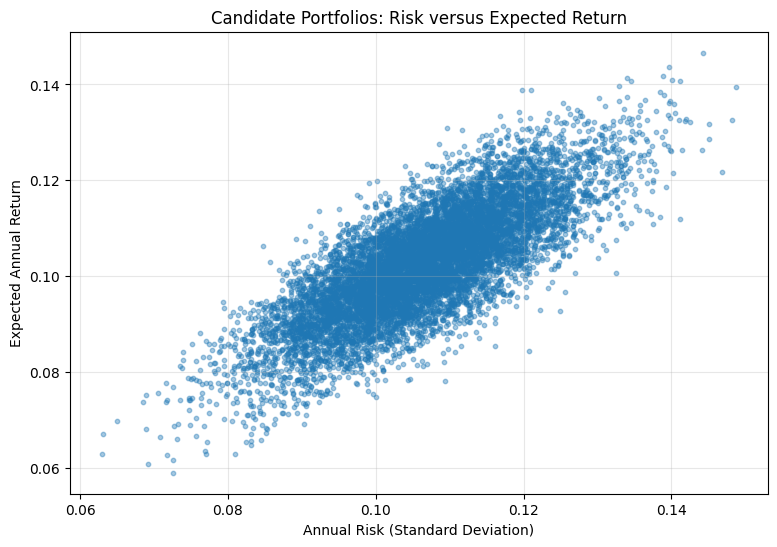

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    candidate_portfolios["Annual Risk"],
    candidate_portfolios["Annual Return"],
    alpha=0.4,
    s=10
)

plt.xlabel("Annual Risk (Standard Deviation)")
plt.ylabel("Expected Annual Return")
plt.title("Candidate Portfolios: Risk versus Expected Return")

plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
min_risk_index = candidate_portfolios["Annual Risk"].idxmin()

min_risk_portfolio = candidate_portfolios.loc[min_risk_index]

print(
    "Minimum-Risk Portfolio"
)

print(
    "Annual Return:",
    f"{min_risk_portfolio['Annual Return']:.2%}"
)

print(
    "Annual Risk:",
    f"{min_risk_portfolio['Annual Risk']:.2%}"
)

print(
    "Weights:",
    min_risk_portfolio["Weights"]
)

Minimum-Risk Portfolio
Annual Return: 6.29%
Annual Risk: 6.29%
Weights: [0.01407239 0.00953469 0.03496177 0.05628249 0.11441207 0.20728394
 0.00679534 0.07896694 0.00715481 0.27687228 0.19366328]


In [ ]:
asset_names = list(asset_mean_returns.index)

for asset, weight in zip(
    asset_names,
    min_risk_portfolio["Weights"]
):
    print(
        f"{asset:25s} {weight:7.2%}"
    )

S&P 500 Index Fund          1.41%
US Large Cap                0.95%
US Small Cap                3.50%
International Stocks        5.63%
Bonds                      11.44%
Cash                       20.73%
REITs                       0.68%
Growth Stocks               7.90%
Value Stocks                0.72%
Treasury Bonds             27.69%
Gold                       19.37%


In [ ]:
# Sort portfolios from lowest risk to highest risk
sorted_portfolios = candidate_portfolios.sort_values(
    "Annual Risk"
).reset_index(drop=True)

efficient_rows = []
best_return_so_far = -np.inf

for i, row in sorted_portfolios.iterrows():

    if row["Annual Return"] > best_return_so_far:

        efficient_rows.append(i)

        best_return_so_far = row["Annual Return"]

efficient_frontier = sorted_portfolios.loc[
    efficient_rows
].copy()

print(
    "Candidate portfolios:",
    len(candidate_portfolios)
)

print(
    "Efficient portfolios:",
    len(efficient_frontier)
)

print(
    efficient_frontier[
        ["Annual Risk", "Annual Return"]
    ].head(10)
)

Candidate portfolios: 10000
Efficient portfolios: 34
    Annual Risk  Annual Return
0      0.062935       0.062899
1      0.063123       0.067055
2      0.064975       0.069657
3      0.068522       0.073800
4      0.068901       0.075140
7      0.070564       0.075634
9      0.071608       0.077659
20     0.073570       0.081280
22     0.073952       0.084197
31     0.075178       0.085867


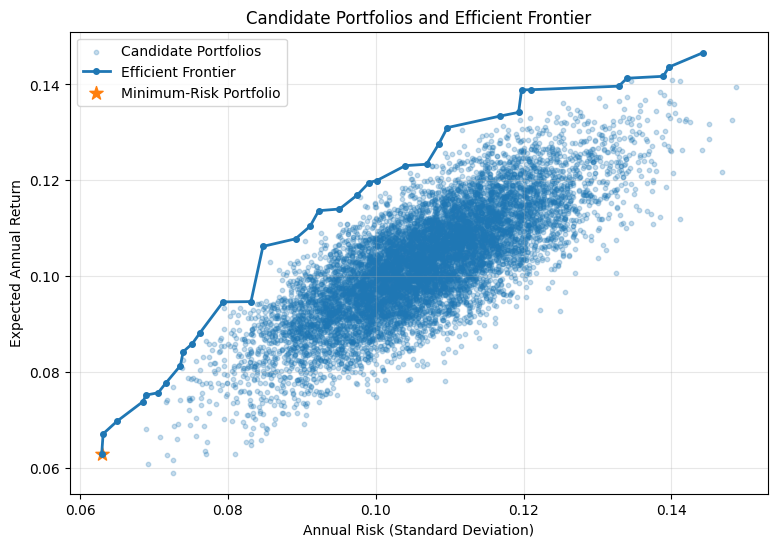

In [ ]:
plt.figure(figsize=(9, 6))

# All candidate portfolios
plt.scatter(
    candidate_portfolios["Annual Risk"],
    candidate_portfolios["Annual Return"],
    alpha=0.25,
    s=10,
    label="Candidate Portfolios"
)

# Empirical efficient frontier
plt.plot(
    efficient_frontier["Annual Risk"],
    efficient_frontier["Annual Return"],
    marker="o",
    markersize=4,
    linewidth=2,
    label="Efficient Frontier"
)

# Minimum-risk portfolio
plt.scatter(
    min_risk_portfolio["Annual Risk"],
    min_risk_portfolio["Annual Return"],
    s=100,
    marker="*",
    label="Minimum-Risk Portfolio"
)

plt.xlabel("Annual Risk (Standard Deviation)")
plt.ylabel("Expected Annual Return")
plt.title("Candidate Portfolios and Efficient Frontier")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
from scipy.optimize import minimize

def portfolio_variance(weights, covariance_matrix):
    return (
        weights.T
        @ covariance_matrix.values
        @ weights
    )


num_assets = len(asset_mean_returns)

initial_weights = np.ones(num_assets) / num_assets

constraints = {
    "type": "eq",
    "fun": lambda weights: np.sum(weights) - 1
}

bounds = [
    (0.0, 1.0)
    for _ in range(num_assets)
]

min_variance_result = minimize(
    portfolio_variance,
    initial_weights,
    args=(asset_covariance_matrix,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "ftol": 1e-12,
        "maxiter": 1000
    }
)

print(
    "Optimization successful:",
    min_variance_result.success
)

print(
    "Message:",
    min_variance_result.message
)

Optimization successful: True
Message: Optimization terminated successfully


In [ ]:
optimized_weights = min_variance_result.x

optimized_monthly_return = (
    optimized_weights @ asset_mean_returns.values
)

optimized_monthly_variance = (
    optimized_weights.T
    @ asset_covariance_matrix.values
    @ optimized_weights
)

optimized_monthly_risk = np.sqrt(
    optimized_monthly_variance
)

optimized_annual_return = (
    (1 + optimized_monthly_return) ** 12 - 1
)

optimized_annual_risk = (
    optimized_monthly_risk * np.sqrt(12)
)

print("Optimized Minimum-Variance Portfolio")
print(
    "Annual Return:",
    f"{optimized_annual_return:.2%}"
)
print(
    "Annual Risk:",
    f"{optimized_annual_risk:.2%}"
)
print(
    "Weight Sum:",
    optimized_weights.sum()
)

print("\nPortfolio Weights")

for asset, weight in zip(
    asset_mean_returns.index,
    optimized_weights
):
    print(
        f"{asset:25s} {weight:7.2%}"
    )

Optimized Minimum-Variance Portfolio
Annual Return: 2.31%
Annual Risk: 0.56%
Weight Sum: 1.0

Portfolio Weights
S&P 500 Index Fund          0.00%
US Large Cap                0.00%
US Small Cap                0.09%
International Stocks        0.00%
Bonds                       0.00%
Cash                       99.67%
REITs                       0.00%
Growth Stocks               0.00%
Value Stocks                0.24%
Treasury Bonds              0.00%
Gold                        0.00%


In [ ]:
optimized_weight_dict = dict(
    zip(
        asset_mean_returns.index,
        optimized_weights
    )
)

(
    check_monthly_return,
    check_monthly_variance,
    check_monthly_std
) = calculate_portfolio_statistics(
    optimized_weight_dict,
    asset_mean_returns,
    asset_covariance_matrix
)

check_annual_return = (
    (1 + check_monthly_return) ** 12 - 1
)

check_annual_risk = (
    check_monthly_std * np.sqrt(12)
)

print(
    "Independent Annual Return:",
    f"{check_annual_return:.2%}"
)

print(
    "Independent Annual Risk:",
    f"{check_annual_risk:.2%}"
)

print(
    "Weight Sum:",
    sum(optimized_weight_dict.values())
)

Independent Annual Return: 1.66%
Independent Annual Risk: 3.11%
Weight Sum: 1.0


In [ ]:
def optimize_for_target_return(
    target_annual_return,
    mean_returns,
    covariance_matrix
):
    num_assets = len(mean_returns)

    # Convert annual target return to monthly
    target_monthly_return = (
        (1 + target_annual_return) ** (1 / 12) - 1
    )

    initial_weights = (
        np.ones(num_assets) / num_assets
    )

    constraints = [
        {
            "type": "eq",
            "fun": lambda weights:
                np.sum(weights) - 1
        },
        {
            "type": "eq",
            "fun": lambda weights:
                weights @ mean_returns.values
                - target_monthly_return
        }
    ]

    bounds = [
        (0.0, 1.0)
        for _ in range(num_assets)
    ]

    result = minimize(
        portfolio_variance,
        initial_weights,
        args=(covariance_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    return result

In [ ]:
def optimize_for_target_return(
    target_annual_return,
    mean_returns,
    covariance_matrix,
    initial_weights=None,
    bounds=None
):
    num_assets = len(mean_returns)

    target_monthly_return = (
        (1 + target_annual_return) ** (1 / 12) - 1
    )

    if initial_weights is None:
        initial_weights = (
            np.ones(num_assets) / num_assets
        )

    if bounds is None:
        bounds = [
            (0.0, 1.0)
            for _ in range(num_assets)
        ]

    constraints = [
        {
            "type": "eq",
            "fun": lambda weights:
                np.sum(weights) - 1
        },
        {
            "type": "eq",
            "fun": lambda weights:
                weights @ mean_returns.values
                - target_monthly_return
        }
    ]

    result = minimize(
        portfolio_variance,
        initial_weights,
        args=(covariance_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "ftol": 1e-12,
            "maxiter": 1000
        }
    )

    return result

In [ ]:
# -------------------------------------------------
# Build optimized efficient frontier
# using warm starts
# -------------------------------------------------

minimum_return = optimized_annual_return

maximum_monthly_return = asset_mean_returns.max()

maximum_return = (
    (1 + maximum_monthly_return) ** 12 - 1
)

target_returns = np.linspace(
    minimum_return,
    maximum_return,
    50
)

frontier_results = []

# Begin with the validated minimum-variance portfolio
starting_weights = optimized_weights.copy()

for target_return in target_returns:

    result = optimize_for_target_return(
        target_return,
        asset_mean_returns,
        asset_covariance_matrix,
        initial_weights=starting_weights
    )

    if not result.success:
        continue

    weights = result.x

    monthly_return = (
        weights @ asset_mean_returns.values
    )

    monthly_variance = (
        weights.T
        @ asset_covariance_matrix.values
        @ weights
    )

    annual_return = (
        (1 + monthly_return) ** 12 - 1
    )

    annual_risk = (
        np.sqrt(monthly_variance)
        * np.sqrt(12)
    )

    frontier_results.append(
        {
            "Annual Return": annual_return,
            "Annual Risk": annual_risk,
            "Weights": weights.copy()
        }
    )

    # Use this solution to start the next optimization
    starting_weights = weights.copy()


optimized_frontier = pd.DataFrame(
    frontier_results
)

print(
    "Optimized frontier portfolios:",
    len(optimized_frontier)
)

print(
    optimized_frontier[
        ["Annual Risk", "Annual Return"]
    ].head(10)
)

Optimized frontier portfolios: 50
   Annual Risk  Annual Return
0     0.005577       0.023136
1     0.006803       0.026661
2     0.009166       0.030187
3     0.011988       0.033713
4     0.015004       0.037239
5     0.018111       0.040765
6     0.021265       0.044291
7     0.024443       0.047817
8     0.027634       0.051343
9     0.030831       0.054868


In [ ]:
test_target = 0.023902

test_result = optimize_for_target_return(
    test_target,
    asset_mean_returns,
    asset_covariance_matrix,
    initial_weights=optimized_weights
)

test_weights = test_result.x

actual_weight_sum = np.sum(test_weights)

actual_monthly_return = (
    test_weights @ asset_mean_returns.values
)

target_monthly_return = (
    (1 + test_target) ** (1 / 12) - 1
)

actual_annual_return = (
    (1 + actual_monthly_return) ** 12 - 1
)

actual_annual_risk = (
    np.sqrt(
        test_weights.T
        @ asset_covariance_matrix.values
        @ test_weights
    )
    * np.sqrt(12)
)

print("Success:", test_result.success)
print("Message:", test_result.message)
print("Weight Sum:", actual_weight_sum)
print("Weight Sum Error:", actual_weight_sum - 1.0)
print("Target Annual Return:", f"{test_target:.6%}")
print("Actual Annual Return:", f"{actual_annual_return:.6%}")
print(
    "Return Constraint Error:",
    actual_monthly_return - target_monthly_return
)
print("Annual Risk:", f"{actual_annual_risk:.6%}")

Success: True
Message: Optimization terminated successfully
Weight Sum: 1.0000000000000002
Weight Sum Error: 2.220446049250313e-16
Target Annual Return: 2.390200%
Actual Annual Return: 2.390200%
Return Constraint Error: -9.365338365929787e-15
Annual Risk: 0.566373%


In [ ]:
cash_monthly_return = asset_mean_returns["Cash"]

cash_monthly_std = np.sqrt(
    asset_covariance_matrix.loc["Cash", "Cash"]
)

cash_annual_return = (
    (1 + cash_monthly_return) ** 12 - 1
)

cash_annual_std = (
    cash_monthly_std * np.sqrt(12)
)

print(
    "Cash Annual Return:",
    f"{cash_annual_return:.2%}"
)

print(
    "Cash Annual Risk:",
    f"{cash_annual_std:.2%}"
)

Cash Annual Return: 2.28%
Cash Annual Risk: 0.56%


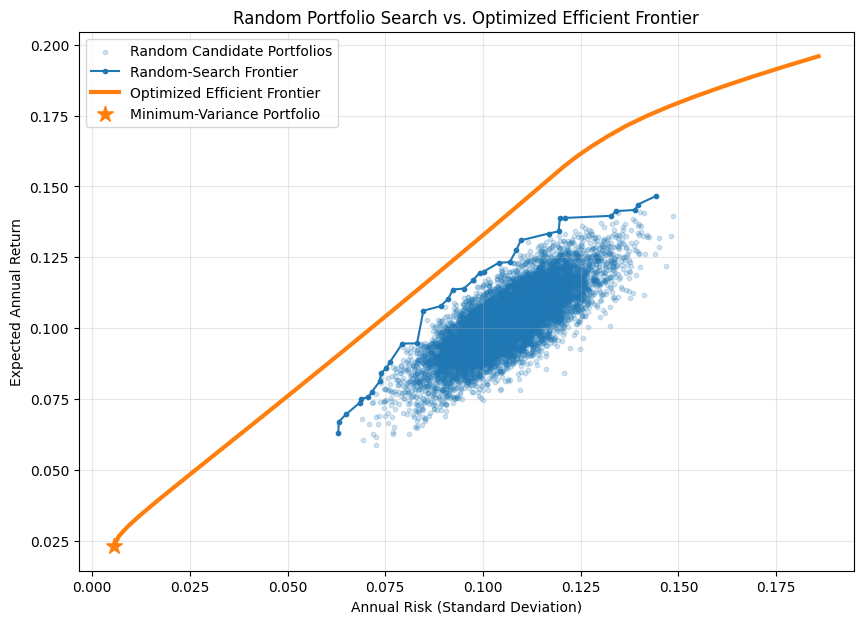

In [ ]:
plt.figure(figsize=(10, 7))

# 10,000 randomly generated candidate portfolios
plt.scatter(
    candidate_portfolios["Annual Risk"],
    candidate_portfolios["Annual Return"],
    alpha=0.20,
    s=10,
    label="Random Candidate Portfolios"
)

# Empirical frontier from random portfolios
plt.plot(
    efficient_frontier["Annual Risk"],
    efficient_frontier["Annual Return"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Random-Search Frontier"
)

# True optimized efficient frontier
plt.plot(
    optimized_frontier["Annual Risk"],
    optimized_frontier["Annual Return"],
    linewidth=3,
    label="Optimized Efficient Frontier"
)

# Corrected minimum-variance portfolio
plt.scatter(
    optimized_annual_risk,
    optimized_annual_return,
    s=140,
    marker="*",
    label="Minimum-Variance Portfolio"
)

plt.xlabel("Annual Risk (Standard Deviation)")
plt.ylabel("Expected Annual Return")
plt.title(
    "Random Portfolio Search vs. Optimized Efficient Frontier"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
annual_asset_returns = (
    (1 + asset_mean_returns) ** 12 - 1
)

print("Annualized Expected Returns")
print("---------------------------")

for asset, annual_return in annual_asset_returns.sort_values().items():
    print(
        f"{asset:25s} {annual_return:7.2%}"
    )

Annualized Expected Returns
---------------------------
Treasury Bonds              0.65%
Bonds                       1.57%
Cash                        2.28%
REITs                       7.11%
International Stocks       10.52%
Gold                       12.91%
US Small Cap               13.11%
Value Stocks               13.89%
US Large Cap               16.67%
S&P 500 Index Fund         16.67%
Growth Stocks              19.59%


In [ ]:
risk_limits = {
    "Low": 0.08,
    "Moderate": 0.12,
    "High": 0.18
}

def select_frontier_portfolio(
    optimized_frontier,
    risk_tolerance
):
    risk_limit = risk_limits[risk_tolerance]

    eligible = optimized_frontier[
        optimized_frontier["Annual Risk"] <= risk_limit
    ]

    if eligible.empty:
        return None

    # Highest expected return that remains
    # within the specified risk limit
    selected = eligible.loc[
        eligible["Annual Return"].idxmax()
    ]

    return selected

In [ ]:
for tolerance in [
    "Low",
    "Moderate",
    "High"
]:
    selected = select_frontier_portfolio(
        optimized_frontier,
        tolerance
    )

    print("\n", tolerance)

    print(
        "Expected Return:",
        f"{selected['Annual Return']:.2%}"
    )

    print(
        "Annual Risk:",
        f"{selected['Annual Risk']:.2%}"
    )


 Low
Expected Return: 10.78%
Annual Risk: 7.82%

 Moderate
Expected Return: 15.36%
Annual Risk: 11.78%

 High
Expected Return: 19.24%
Annual Risk: 17.74%


In [ ]:
for tolerance in [
    "Low",
    "Moderate",
    "High"
]:

    risk_limit = risk_limits[tolerance]

    eligible = constrained_frontier[
        constrained_frontier["Annual Risk"]
        <= risk_limit
    ]

    selected = eligible.loc[
        eligible["Annual Return"].idxmax()
    ]

    print(f"\n{tolerance} Risk Portfolio")

    print(
        "Expected Return:",
        f"{selected['Annual Return']:.2%}"
    )

    print(
        "Annual Risk:",
        f"{selected['Annual Risk']:.2%}"
    )

    print("\nAsset Allocation")

    for asset, weight in zip(
        optimization_mean_returns.index,
        selected["Weights"]
    ):
        if weight > 0.001:
            print(
                f"{asset:25s} {weight:7.2%}"
            )


Low Risk Portfolio
Expected Return: 10.73%
Annual Risk: 7.78%

Asset Allocation
Cash                       35.00%
Growth Stocks              24.06%
Value Stocks               13.23%
Gold                       27.71%

Moderate Risk Portfolio
Expected Return: 15.34%
Annual Risk: 11.83%

Asset Allocation
S&P 500 Index Fund          9.52%
Cash                        3.52%
Growth Stocks              35.00%
Value Stocks               16.96%
Gold                       35.00%

High Risk Portfolio
Expected Return: 16.76%
Annual Risk: 14.67%

Asset Allocation
S&P 500 Index Fund         35.00%
Growth Stocks              35.00%
Value Stocks               21.85%
Gold                        8.15%


In [ ]:
OPTIMIZATION_ASSETS = [
    "S&P 500 Index Fund",
    "US Small Cap",
    "International Stocks",
    "Bonds",
    "Cash",
    "REITs",
    "Growth Stocks",
    "Value Stocks",
    "Treasury Bonds",
    "Gold",
]

optimization_mean_returns = (
    asset_mean_returns.reindex(
        OPTIMIZATION_ASSETS
    )
)

optimization_covariance_matrix = (
    asset_covariance_matrix.reindex(
        index=OPTIMIZATION_ASSETS,
        columns=OPTIMIZATION_ASSETS
    )
)

print("Optimization Assets")
print("-------------------")

for asset in optimization_mean_returns.index:
    print(asset)

Optimization Assets
-------------------
S&P 500 Index Fund
US Small Cap
International Stocks
Bonds
Cash
REITs
Growth Stocks
Value Stocks
Treasury Bonds
Gold


In [ ]:
num_optimization_assets = len(
    optimization_mean_returns
)

optimization_initial_weights = (
    np.ones(num_optimization_assets)
    / num_optimization_assets
)

optimization_bounds = [
    (0.0, 1.0)
    for _ in range(num_optimization_assets)
]

optimization_constraints = {
    "type": "eq",
    "fun": lambda weights:
        np.sum(weights) - 1
}

clean_min_variance_result = minimize(
    portfolio_variance,
    optimization_initial_weights,
    args=(optimization_covariance_matrix,),
    method="SLSQP",
    bounds=optimization_bounds,
    constraints=optimization_constraints,
    options={
        "ftol": 1e-12,
        "maxiter": 1000
    }
)

clean_weights = clean_min_variance_result.x

clean_monthly_return = (
    clean_weights
    @ optimization_mean_returns.values
)

clean_monthly_variance = (
    clean_weights.T
    @ optimization_covariance_matrix.values
    @ clean_weights
)

clean_annual_return = (
    (1 + clean_monthly_return) ** 12 - 1
)

clean_annual_risk = (
    np.sqrt(clean_monthly_variance)
    * np.sqrt(12)
)

print(
    "Optimization successful:",
    clean_min_variance_result.success
)

print(
    "Annual Return:",
    f"{clean_annual_return:.2%}"
)

print(
    "Annual Risk:",
    f"{clean_annual_risk:.2%}"
)

print(
    "Weight Sum:",
    clean_weights.sum()
)

print("\nPortfolio Weights")

for asset, weight in zip(
    optimization_mean_returns.index,
    clean_weights
):
    if weight > 0.001:
        print(
            f"{asset:25s} {weight:7.2%}"
        )

Optimization successful: True
Annual Return: 2.31%
Annual Risk: 0.56%
Weight Sum: 1.0

Portfolio Weights
Cash                       99.67%
Value Stocks                0.24%


In [ ]:
concentration_limit = 0.35

constrained_bounds = [
    (0.0, concentration_limit)
    for _ in range(
        len(optimization_mean_returns)
    )
]

constrained_min_variance_result = minimize(
    portfolio_variance,
    optimization_initial_weights,
    args=(optimization_covariance_matrix,),
    method="SLSQP",
    bounds=constrained_bounds,
    constraints=optimization_constraints,
    options={
        "ftol": 1e-12,
        "maxiter": 1000
    }
)

constrained_weights = (
    constrained_min_variance_result.x
)

constrained_monthly_return = (
    constrained_weights
    @ optimization_mean_returns.values
)

constrained_monthly_variance = (
    constrained_weights.T
    @ optimization_covariance_matrix.values
    @ constrained_weights
)

constrained_annual_return = (
    (1 + constrained_monthly_return) ** 12 - 1
)

constrained_annual_risk = (
    np.sqrt(constrained_monthly_variance)
    * np.sqrt(12)
)

print(
    "Optimization successful:",
    constrained_min_variance_result.success
)

print(
    "Annual Return:",
    f"{constrained_annual_return:.2%}"
)

print(
    "Annual Risk:",
    f"{constrained_annual_risk:.2%}"
)

print(
    "Weight Sum:",
    constrained_weights.sum()
)

print("\nPortfolio Weights")

for asset, weight in zip(
    optimization_mean_returns.index,
    constrained_weights
):
    if weight > 0.001:
        print(
            f"{asset:25s} {weight:7.2%}"
        )

Optimization successful: True
Annual Return: 2.23%
Annual Risk: 3.66%
Weight Sum: 0.9999999999999998

Portfolio Weights
Bonds                      35.00%
Cash                       35.00%
Value Stocks                5.46%
Treasury Bonds             24.54%


In [ ]:
minimum_return = constrained_annual_return

maximum_return = (
    (1 + optimization_mean_returns.max()) ** 12 - 1
)

target_returns = np.linspace(
    minimum_return,
    maximum_return,
    50
)

constrained_frontier_results = []

starting_weights = constrained_weights.copy()

for target_return in target_returns:

    result = optimize_for_target_return(
        target_return,
        optimization_mean_returns,
        optimization_covariance_matrix,
        initial_weights=starting_weights,
        bounds=constrained_bounds
    )

    if not result.success:
        continue

    weights = result.x

    monthly_return = (
        weights @ optimization_mean_returns.values
    )

    monthly_variance = (
        weights.T
        @ optimization_covariance_matrix.values
        @ weights
    )

    annual_return = (
        (1 + monthly_return) ** 12 - 1
    )

    annual_risk = (
        np.sqrt(monthly_variance)
        * np.sqrt(12)
    )

    constrained_frontier_results.append(
        {
            "Annual Return": annual_return,
            "Annual Risk": annual_risk,
            "Weights": weights.copy()
        }
    )

    starting_weights = weights.copy()

constrained_frontier = pd.DataFrame(
    constrained_frontier_results
)

print(
    "Constrained frontier portfolios:",
    len(constrained_frontier)
)

print(
    constrained_frontier[
        ["Annual Risk", "Annual Return"]
    ].head(10)
)

Constrained frontier portfolios: 42
   Annual Risk  Annual Return
0     0.036609       0.022277
1     0.036790       0.025821
2     0.037246       0.029364
3     0.037960       0.032907
4     0.038917       0.036451
5     0.040094       0.039994
6     0.041432       0.043538
7     0.042900       0.047081
8     0.044484       0.050624
9     0.046167       0.054168


In [ ]:
selected_portfolios = {}

for tolerance in [
    "Low",
    "Moderate",
    "High"
]:

    risk_limit = risk_limits[tolerance]

    eligible = constrained_frontier[
        constrained_frontier["Annual Risk"]
        <= risk_limit
    ]

    selected = eligible.loc[
        eligible["Annual Return"].idxmax()
    ]

    selected_portfolios[tolerance] = {
        "mean_return": float(
            selected["Annual Return"]
        ),
        "std_return": float(
            selected["Annual Risk"]
        ),
        "weights": selected["Weights"]
    }

In [ ]:
for tolerance, portfolio in selected_portfolios.items():

    final_values = simulate_portfolio(
        initial_balance=100000,
        monthly_contribution=200,
        years=20,
        mean_return=portfolio["mean_return"],
        std_return=portfolio["std_return"],
        num_simulations=10000,
        random_seed=42
    )

    probability = np.mean(
        final_values >= 600000
    )

    print(f"\n{tolerance} Risk Portfolio")

    print(
        "Expected Return:",
        f"{portfolio['mean_return']:.2%}"
    )

    print(
        "Estimated Risk:",
        f"{portfolio['std_return']:.2%}"
    )

    print(
        "Median Final Value:",
        f"${np.median(final_values):,.2f}"
    )

    print(
        "Probability of Reaching Goal:",
        f"{probability:.2%}"
    )


Low Risk Portfolio
Expected Return: 10.73%
Estimated Risk: 7.78%
Median Final Value: $884,290.18
Probability of Reaching Goal: 90.35%

Moderate Risk Portfolio
Expected Return: 15.34%
Estimated Risk: 11.83%
Median Final Value: $1,819,370.79
Probability of Reaching Goal: 99.43%

High Risk Portfolio
Expected Return: 16.76%
Estimated Risk: 14.67%
Median Final Value: $2,187,006.31
Probability of Reaching Goal: 99.04%


In [ ]:
goal_amount = 600000

goal_probabilities = []

for _, row in constrained_frontier.iterrows():

    final_values = simulate_portfolio(
        initial_balance=100000,
        monthly_contribution=200,
        years=20,
        mean_return=row["Annual Return"],
        std_return=row["Annual Risk"],
        num_simulations=10000,
        random_seed=42
    )

    probability = np.mean(
        final_values >= goal_amount
    )

    goal_probabilities.append(
        probability
    )

constrained_frontier[
    "Goal Probability"
] = goal_probabilities


print(
    constrained_frontier[
        [
            "Annual Risk",
            "Annual Return",
            "Goal Probability"
        ]
    ].to_string(
        index=False,
        formatters={
            "Annual Risk":
                lambda x: f"{x:.2%}",
            "Annual Return":
                lambda x: f"{x:.2%}",
            "Goal Probability":
                lambda x: f"{x:.2%}"
        }
    )
)

Annual Risk Annual Return Goal Probability
      3.66%         2.23%            0.00%
      3.68%         2.58%            0.00%
      3.72%         2.94%            0.00%
      3.80%         3.29%            0.00%
      3.89%         3.65%            0.00%
      4.01%         4.00%            0.00%
      4.14%         4.35%            0.00%
      4.29%         4.71%            0.01%
      4.45%         5.06%            0.07%
      4.62%         5.42%            0.36%
      4.80%         5.77%            1.04%
      4.99%         6.13%            2.67%
      5.18%         6.48%            5.79%
      5.38%         6.83%           10.90%
      5.59%         7.19%           17.73%
      5.79%         7.54%           26.61%
      6.00%         7.90%           36.20%
      6.21%         8.25%           46.37%
      6.43%         8.61%           55.75%
      6.64%         8.96%           64.50%
      6.86%         9.31%           72.05%
      7.08%         9.67%           78.38%
      7.30%

In [ ]:
desired_success_probability = 0.90

eligible_goal_portfolios = constrained_frontier[
    constrained_frontier["Goal Probability"]
    >= desired_success_probability
]

if eligible_goal_portfolios.empty:

    print(
        "No portfolio reaches the desired "
        "success probability."
    )

else:

    goal_based_portfolio = (
        eligible_goal_portfolios.loc[
            eligible_goal_portfolios[
                "Annual Risk"
            ].idxmin()
        ]
    )

    print("Goal-Based Portfolio")
    print("--------------------")

    print(
        "Required Success Probability:",
        f"{desired_success_probability:.0%}"
    )

    print(
        "Expected Return:",
        f"{goal_based_portfolio['Annual Return']:.2%}"
    )

    print(
        "Annual Risk:",
        f"{goal_based_portfolio['Annual Risk']:.2%}"
    )

    print(
        "Goal Probability:",
        f"{goal_based_portfolio['Goal Probability']:.2%}"
    )

    print("\nAsset Allocation")

    for asset, weight in zip(
        optimization_mean_returns.index,
        goal_based_portfolio["Weights"]
    ):
        if weight > 0.001:
            print(
                f"{asset:25s} {weight:7.2%}"
            )

Goal-Based Portfolio
--------------------
Required Success Probability: 90%
Expected Return: 10.73%
Annual Risk: 7.78%
Goal Probability: 90.35%

Asset Allocation
Cash                       35.00%
Growth Stocks              24.06%
Value Stocks               13.23%
Gold                       27.71%


In [ ]:
def select_goal_based_portfolio(
    frontier,
    desired_success_probability
):
    eligible = frontier[
        frontier["Goal Probability"]
        >= desired_success_probability
    ]

    if eligible.empty:
        return None

    selected = eligible.loc[
        eligible["Annual Risk"].idxmin()
    ]

    return selected

In [ ]:
goal_based_portfolio = select_goal_based_portfolio(
    constrained_frontier,
    0.90
)

print("Goal-Based Portfolio")
print("--------------------")

print(
    "Expected Return:",
    f"{goal_based_portfolio['Annual Return']:.2%}"
)

print(
    "Annual Risk:",
    f"{goal_based_portfolio['Annual Risk']:.2%}"
)

print(
    "Goal Probability:",
    f"{goal_based_portfolio['Goal Probability']:.2%}"
)

print("\nAsset Allocation")

for asset, weight in zip(
    optimization_mean_returns.index,
    goal_based_portfolio["Weights"]
):
    if weight > 0.001:
        print(f"{asset:25s} {weight:7.2%}")

Goal-Based Portfolio
--------------------
Expected Return: 10.73%
Annual Risk: 7.78%
Goal Probability: 90.35%

Asset Allocation
Cash                       35.00%
Growth Stocks              24.06%
Value Stocks               13.23%
Gold                       27.71%


In [ ]:
def evaluate_frontier_goal_probabilities(
    frontier,
    initial_balance,
    monthly_contribution,
    years,
    goal_amount,
    num_simulations=10000,
    random_seed=42
):
    evaluated_frontier = frontier.copy()

    goal_probabilities = []

    for _, row in evaluated_frontier.iterrows():

        final_values = simulate_portfolio(
            initial_balance=initial_balance,
            monthly_contribution=monthly_contribution,
            years=years,
            mean_return=row["Annual Return"],
            std_return=row["Annual Risk"],
            num_simulations=num_simulations,
            random_seed=random_seed
        )

        probability = np.mean(
            final_values >= goal_amount
        )

        goal_probabilities.append(probability)

    evaluated_frontier[
        "Goal Probability"
    ] = goal_probabilities

    return evaluated_frontier

In [ ]:
test_frontier = evaluate_frontier_goal_probabilities(
    constrained_frontier,
    initial_balance=100000,
    monthly_contribution=200,
    years=20,
    goal_amount=600000,
    num_simulations=10000,
    random_seed=42
)

print(
    test_frontier[
        [
            "Annual Risk",
            "Annual Return",
            "Goal Probability"
        ]
    ].tail(5)
)

    Annual Risk  Annual Return  Goal Probability
37     0.118313       0.153382            0.9943
38     0.121534       0.156926            0.9954
39     0.124814       0.160469            0.9963
40     0.128799       0.164013            0.9964
41     0.146723       0.167556            0.9904


In [ ]:
def build_constrained_frontier(
    mean_returns,
    covariance_matrix,
    concentration_limit=0.35,
    num_portfolios=50
):
    num_assets = len(mean_returns)

    initial_weights = (
        np.ones(num_assets) / num_assets
    )

    bounds = [
        (0.0, concentration_limit)
        for _ in range(num_assets)
    ]

    sum_constraint = {
        "type": "eq",
        "fun": lambda weights:
            np.sum(weights) - 1
    }

    # Find constrained minimum-variance portfolio
    min_result = minimize(
        portfolio_variance,
        initial_weights,
        args=(covariance_matrix,),
        method="SLSQP",
        bounds=bounds,
        constraints=sum_constraint,
        options={
            "ftol": 1e-12,
            "maxiter": 1000
        }
    )

    if not min_result.success:
        raise ValueError(
            "Minimum-variance optimization failed."
        )

    min_weights = min_result.x

    min_monthly_return = (
        min_weights @ mean_returns.values
    )

    min_annual_return = (
        (1 + min_monthly_return) ** 12 - 1
    )

    max_annual_return = (
        (1 + mean_returns.max()) ** 12 - 1
    )

    target_returns = np.linspace(
        min_annual_return,
        max_annual_return,
        num_portfolios
    )

    frontier_results = []

    starting_weights = min_weights.copy()

    for target_return in target_returns:

        result = optimize_for_target_return(
            target_return,
            mean_returns,
            covariance_matrix,
            initial_weights=starting_weights,
            bounds=bounds
        )

        if not result.success:
            continue

        weights = result.x

        monthly_return = (
            weights @ mean_returns.values
        )

        monthly_variance = (
            weights.T
            @ covariance_matrix.values
            @ weights
        )

        annual_return = (
            (1 + monthly_return) ** 12 - 1
        )

        annual_risk = (
            np.sqrt(monthly_variance)
            * np.sqrt(12)
        )

        frontier_results.append(
            {
                "Annual Return": annual_return,
                "Annual Risk": annual_risk,
                "Weights": weights.copy()
            }
        )

        starting_weights = weights.copy()

    return pd.DataFrame(frontier_results)

In [ ]:
test_constrained_frontier = (
    build_constrained_frontier(
        optimization_mean_returns,
        optimization_covariance_matrix,
        concentration_limit=0.35,
        num_portfolios=50
    )
)

print(
    "Constrained frontier portfolios:",
    len(test_constrained_frontier)
)

print(
    test_constrained_frontier[
        [
            "Annual Risk",
            "Annual Return"
        ]
    ].head(10)
)

Constrained frontier portfolios: 42
   Annual Risk  Annual Return
0     0.036609       0.022277
1     0.036790       0.025821
2     0.037246       0.029364
3     0.037960       0.032907
4     0.038917       0.036451
5     0.040094       0.039994
6     0.041432       0.043538
7     0.042900       0.047081
8     0.044484       0.050624
9     0.046167       0.054168


In [ ]:
integration_frontier = build_constrained_frontier(
    optimization_mean_returns,
    optimization_covariance_matrix,
    concentration_limit=0.35,
    num_portfolios=50
)

integration_frontier = evaluate_frontier_goal_probabilities(
    integration_frontier,
    initial_balance=100000,
    monthly_contribution=200,
    years=20,
    goal_amount=600000,
    num_simulations=10000,
    random_seed=42
)

integration_portfolio = select_goal_based_portfolio(
    integration_frontier,
    0.90
)

print("Integrated Goal-Based Optimization Test")
print("--------------------------------------")

print(
    "Expected Return:",
    f"{integration_portfolio['Annual Return']:.2%}"
)

print(
    "Annual Risk:",
    f"{integration_portfolio['Annual Risk']:.2%}"
)

print(
    "Goal Probability:",
    f"{integration_portfolio['Goal Probability']:.2%}"
)

print("\nAsset Allocation")

for asset, weight in zip(
    optimization_mean_returns.index,
    integration_portfolio["Weights"]
):
    if weight > 0.001:
        print(f"{asset:25s} {weight:7.2%}")

Integrated Goal-Based Optimization Test
--------------------------------------
Expected Return: 10.73%
Annual Risk: 7.78%
Goal Probability: 90.35%

Asset Allocation
Cash                       35.00%
Growth Stocks              24.06%
Value Stocks               13.23%
Gold                       27.71%


In [ ]:
def optimize_goal_based_portfolio(
    mean_returns,
    covariance_matrix,
    initial_balance,
    monthly_contribution,
    years,
    goal_amount,
    desired_success_probability=0.90,
    concentration_limit=0.35,
    num_frontier_portfolios=50,
    num_simulations=10000,
    random_seed=42
):
    frontier = build_constrained_frontier(
        mean_returns,
        covariance_matrix,
        concentration_limit=concentration_limit,
        num_portfolios=num_frontier_portfolios
    )

    frontier = evaluate_frontier_goal_probabilities(
        frontier,
        initial_balance=initial_balance,
        monthly_contribution=monthly_contribution,
        years=years,
        goal_amount=goal_amount,
        num_simulations=num_simulations,
        random_seed=random_seed
    )

    selected = select_goal_based_portfolio(
        frontier,
        desired_success_probability
    )

    return selected, frontier

In [ ]:
optimized_portfolio, optimized_frontier_test = (
    optimize_goal_based_portfolio(
        optimization_mean_returns,
        optimization_covariance_matrix,
        initial_balance=100000,
        monthly_contribution=200,
        years=20,
        goal_amount=600000,
        desired_success_probability=0.90,
        concentration_limit=0.35,
        num_frontier_portfolios=50,
        num_simulations=10000,
        random_seed=42
    )
)

print("Financial Wisdom Goal-Based Optimization")
print("----------------------------------------")

print(
    "Expected Return:",
    f"{optimized_portfolio['Annual Return']:.2%}"
)

print(
    "Annual Risk:",
    f"{optimized_portfolio['Annual Risk']:.2%}"
)

print(
    "Goal Probability:",
    f"{optimized_portfolio['Goal Probability']:.2%}"
)

print("\nAsset Allocation")

for asset, weight in zip(
    optimization_mean_returns.index,
    optimized_portfolio["Weights"]
):
    if weight > 0.001:
        print(f"{asset:25s} {weight:7.2%}")

Financial Wisdom Goal-Based Optimization
----------------------------------------
Expected Return: 10.73%
Annual Risk: 7.78%
Goal Probability: 90.35%

Asset Allocation
Cash                       35.00%
Growth Stocks              24.06%
Value Stocks               13.23%
Gold                       27.71%


In [ ]:
print("RANDOM_SEED =", RANDOM_SEED)
print("MIN_ANNUAL_RETURN =", MIN_ANNUAL_RETURN)

RANDOM_SEED = 42
MIN_ANNUAL_RETURN = -0.99


In [ ]:
# ============================================================
# PCA VALIDATION TEST — CLEANED 10-ASSET UNIVERSE
# ============================================================

# Load historical data
asset_returns, asset_mean_returns, asset_std_returns, \
asset_correlation_matrix, asset_covariance_matrix = \
    build_historical_model()


# ------------------------------------------------------------
# Remove duplicate VOO representation
# ------------------------------------------------------------

pca_returns = asset_returns.drop(
    columns=["US Large Cap"]
)

print(
    "\nNumber of assets used for PCA:",
    pca_returns.shape[1]
)


# ------------------------------------------------------------
# Center the data
# ------------------------------------------------------------

centered_returns = (
    pca_returns
    - pca_returns.mean()
)


# ------------------------------------------------------------
# Covariance matrix
# ------------------------------------------------------------

pca_covariance = centered_returns.cov()


# ------------------------------------------------------------
# Eigenvalues and eigenvectors
#
# eigh() returns eigenvalues in ascending order
# ------------------------------------------------------------

eigenvalues, eigenvectors = np.linalg.eigh(
    pca_covariance.values
)


print("\n======================================")
print(" PCA Eigenvalues - Ascending Order")
print("======================================")

for i, value in enumerate(
    eigenvalues,
    start=1
):
    print(
        f"Eigenvalue {i:2d}: "
        f"{value:.8f}"
    )


# ------------------------------------------------------------
# Explained variance
# ------------------------------------------------------------

total_variance = np.sum(eigenvalues)

explained_variance = (
    eigenvalues / total_variance
)


print("\n======================================")
print(" Explained Variance")
print("======================================")

for i, ratio in enumerate(
    explained_variance,
    start=1
):
    print(
        f"Eigenvalue {i:2d}: "
        f"{ratio:.2%}"
    )


# ------------------------------------------------------------
# Largest principal component
# ------------------------------------------------------------

largest_eigenvalue = eigenvalues[-1]

largest_eigenvector = eigenvectors[:, -1]


# Project centered data onto largest eigenvector
projection = (
    centered_returns.values
    @ largest_eigenvector
)


# ------------------------------------------------------------
# Check projection statistics
# ------------------------------------------------------------

projection_mean = np.mean(
    projection
)

projection_variance = np.var(
    projection,
    ddof=1
)


print("\n======================================")
print(" Largest Principal Component Check")
print("======================================")

print(
    f"Largest Eigenvalue:      "
    f"{largest_eigenvalue:.8f}"
)

print(
    f"Projection Mean:         "
    f"{projection_mean:.8f}"
)

print(
    f"Projection Variance:     "
    f"{projection_variance:.8f}"
)

print(
    f"Variance Difference:     "
    f"{abs(largest_eigenvalue - projection_variance):.12f}"
)


Number of assets used for PCA: 10

 PCA Eigenvalues - Ascending Order
Eigenvalue  1: 0.00000225
Eigenvalue  2: 0.00000246
Eigenvalue  3: 0.00000897
Eigenvalue  4: 0.00017697
Eigenvalue  5: 0.00026761
Eigenvalue  6: 0.00035120
Eigenvalue  7: 0.00075197
Eigenvalue  8: 0.00100831
Eigenvalue  9: 0.00212012
Eigenvalue 10: 0.01217537

 Explained Variance
Eigenvalue  1: 0.01%
Eigenvalue  2: 0.01%
Eigenvalue  3: 0.05%
Eigenvalue  4: 1.05%
Eigenvalue  5: 1.59%
Eigenvalue  6: 2.08%
Eigenvalue  7: 4.46%
Eigenvalue  8: 5.98%
Eigenvalue  9: 12.57%
Eigenvalue 10: 72.19%

 Largest Principal Component Check
Largest Eigenvalue:      0.01217537
Projection Mean:         -0.00000000
Projection Variance:     0.01217537
Variance Difference:     0.000000000000


In [ ]:
# ============================================================
# PCA — PRINCIPAL COMPONENT 1 LOADINGS
# ============================================================

# Largest eigenvalue/eigenvector is last because
# np.linalg.eigh() returns eigenvalues in ascending order.

pc1_eigenvalue = eigenvalues[-1]
pc1_eigenvector = eigenvectors[:, -1]

pc1_loadings = pd.Series(
    pc1_eigenvector,
    index=pca_returns.columns,
    name="PC1 Loading"
)

# Sort by absolute magnitude so the assets having the
# strongest relationship with PC1 appear first.
pc1_table = pd.DataFrame({
    "Loading": pc1_loadings,
    "Absolute Loading": np.abs(pc1_loadings)
})

pc1_table = pc1_table.sort_values(
    "Absolute Loading",
    ascending=False
)

print("\n======================================")
print(" Principal Component 1")
print("======================================")

print(
    f"Eigenvalue: "
    f"{pc1_eigenvalue:.8f}"
)

print(
    f"Explained Variance: "
    f"{explained_variance[-1]:.2%}"
)

print("\nPC1 Asset Loadings")

for asset, row in pc1_table.iterrows():
    print(
        f"{asset:25s} "
        f"{row['Loading']: .4f}"
    )


 Principal Component 1
Eigenvalue: 0.01217537
Explained Variance: 72.19%

PC1 Asset Loadings
US Small Cap              -0.4812
Growth Stocks             -0.4313
REITs                     -0.4058
S&P 500 Index Fund        -0.3924
Value Stocks              -0.3550
International Stocks      -0.3526
Gold                      -0.0794
Bonds                     -0.0721
Treasury Bonds            -0.0442
Cash                       0.0002


In [ ]:
# ============================================================
# PCA — PRINCIPAL COMPONENT 2 LOADINGS
# ============================================================

# Second-largest eigenvalue/eigenvector
pc2_eigenvalue = eigenvalues[-2]
pc2_eigenvector = eigenvectors[:, -2]

pc2_loadings = pd.Series(
    pc2_eigenvector,
    index=pca_returns.columns,
    name="PC2 Loading"
)

pc2_table = pd.DataFrame({
    "Loading": pc2_loadings,
    "Absolute Loading": np.abs(pc2_loadings)
})

pc2_table = pc2_table.sort_values(
    "Absolute Loading",
    ascending=False
)

print("\n======================================")
print(" Principal Component 2")
print("======================================")

print(
    f"Eigenvalue: "
    f"{pc2_eigenvalue:.8f}"
)

print(
    f"Explained Variance: "
    f"{explained_variance[-2]:.2%}"
)

print("\nPC2 Asset Loadings")

for asset, row in pc2_table.iterrows():
    print(
        f"{asset:25s} "
        f"{row['Loading']: .4f}"
    )


# ------------------------------------------------------------
# Projection check
# ------------------------------------------------------------

pc2_projection = (
    centered_returns.values
    @ pc2_eigenvector
)

print("\nPC2 Projection Check")

print(
    f"Projection Mean:     "
    f"{np.mean(pc2_projection):.8f}"
)

print(
    f"Projection Variance: "
    f"{np.var(pc2_projection, ddof=1):.8f}"
)


 Principal Component 2
Eigenvalue: 0.00212012
Explained Variance: 12.57%

PC2 Asset Loadings
Gold                       0.9107
Treasury Bonds             0.2037
US Small Cap              -0.2034
International Stocks       0.1843
Bonds                      0.1447
REITs                      0.1038
Growth Stocks             -0.0871
S&P 500 Index Fund        -0.0848
Value Stocks              -0.0848
Cash                       0.0071

PC2 Projection Check
Projection Mean:     -0.00000000
Projection Variance: 0.00212012


In [ ]:
# ============================================================
# PCA — PRINCIPAL COMPONENT 3 LOADINGS
# ============================================================

# Third-largest eigenvalue/eigenvector
pc3_eigenvalue = eigenvalues[-3]
pc3_eigenvector = eigenvectors[:, -3]

pc3_loadings = pd.Series(
    pc3_eigenvector,
    index=pca_returns.columns,
    name="PC3 Loading"
)

pc3_table = pd.DataFrame({
    "Loading": pc3_loadings,
    "Absolute Loading": np.abs(pc3_loadings)
})

pc3_table = pc3_table.sort_values(
    "Absolute Loading",
    ascending=False
)

print("\n======================================")
print(" Principal Component 3")
print("======================================")

print(
    f"Eigenvalue: "
    f"{pc3_eigenvalue:.8f}"
)

print(
    f"Explained Variance: "
    f"{explained_variance[-3]:.2%}"
)

print("\nPC3 Asset Loadings")

for asset, row in pc3_table.iterrows():
    print(
        f"{asset:25s} "
        f"{row['Loading']: .4f}"
    )


# ------------------------------------------------------------
# Projection check
# ------------------------------------------------------------

pc3_projection = (
    centered_returns.values
    @ pc3_eigenvector
)

print("\nPC3 Projection Check")

print(
    f"Projection Mean:     "
    f"{np.mean(pc3_projection):.8f}"
)

print(
    f"Projection Variance: "
    f"{np.var(pc3_projection, ddof=1):.8f}"
)


# ------------------------------------------------------------
# Cumulative variance of first three PCs
# ------------------------------------------------------------

first_three_variance = (
    explained_variance[-1]
    + explained_variance[-2]
    + explained_variance[-3]
)

print(
    f"\nVariance Explained by PC1-PC3: "
    f"{first_three_variance:.2%}"
)


 Principal Component 3
Eigenvalue: 0.00100831
Explained Variance: 5.98%

PC3 Asset Loadings
Growth Stocks             -0.7451
REITs                      0.4862
Value Stocks               0.2830
S&P 500 Index Fund        -0.2561
US Small Cap               0.2251
Gold                      -0.0794
International Stocks       0.0678
Treasury Bonds            -0.0327
Cash                      -0.0059
Bonds                     -0.0057

PC3 Projection Check
Projection Mean:     0.00000000
Projection Variance: 0.00100831

Variance Explained by PC1-PC3: 90.74%


In [ ]:
# ============================================================
# TEST — OPTIMIZED PORTFOLIO PCA EXPOSURE
# ============================================================

# Previously validated $1,000,000 goal portfolio
test_weights = {
    "S&P 500 Index Fund": 0.0952,
    "Cash": 0.0352,
    "Growth Stocks": 0.3500,
    "Value Stocks": 0.1696,
    "Gold": 0.3500,
}

# Put weights in exactly the same asset order used by PCA.
w = np.array([
    test_weights.get(asset, 0.0)
    for asset in pca_returns.columns
])

# Principal-component eigenvectors.
# Eigenvalues/eigenvectors are currently in ascending order.
pc1 = eigenvectors[:, -1]
pc2 = eigenvectors[:, -2]
pc3 = eigenvectors[:, -3]

# Portfolio exposure to each principal direction
exposure_pc1 = np.dot(w, pc1)
exposure_pc2 = np.dot(w, pc2)
exposure_pc3 = np.dot(w, pc3)

print("\n======================================")
print(" Portfolio PCA Exposure")
print("======================================")

print(f"PC1 Exposure: {exposure_pc1: .4f}")
print(f"PC2 Exposure: {exposure_pc2: .4f}")
print(f"PC3 Exposure: {exposure_pc3: .4f}")

print("\nPortfolio weights used:")

for asset, weight in zip(pca_returns.columns, w):
    if weight > 0:
        print(f"{asset:25s} {weight:7.2%}")


 Portfolio PCA Exposure
PC1 Exposure: -0.2763
PC2 Exposure:  0.2661
PC3 Exposure: -0.2652

Portfolio weights used:
S&P 500 Index Fund          9.52%
Cash                        3.52%
Growth Stocks              35.00%
Value Stocks               16.96%
Gold                       35.00%


In [12]:
# ============================================================
# PCA — PORTFOLIO VARIANCE BY PRINCIPAL COMPONENT
# ============================================================

# Portfolio exposure to every principal component
pc_exposures = eigenvectors.T @ w

# Variance contributed by each principal component
pc_variance = eigenvalues * (pc_exposures ** 2)

# Total portfolio variance reconstructed from PCA
total_pca_variance = np.sum(pc_variance)

# Percentage contribution of each PC to portfolio variance
pc_risk_fraction = pc_variance / total_pca_variance

# Display largest PCs first
print("\n======================================")
print(" Portfolio Risk by Principal Component")
print("======================================")

for i in range(1, len(eigenvalues) + 1):

    index = -i

    print(
        f"PC{i:2d}: "
        f"Exposure = {pc_exposures[index]: .4f}   "
        f"Variance Share = {pc_risk_fraction[index]:6.2%}"
    )

print("\n======================================")
print(" PCA Variance Reconstruction Check")
print("======================================")

print(
    f"PCA Portfolio Variance: "
    f"{total_pca_variance:.8f}"
)

direct_variance = (
    w.T
    @ pca_returns.cov().values
    @ w
)

print(
    f"Direct Portfolio Variance: "
    f"{direct_variance:.8f}"
)

print(
    f"Difference: "
    f"{abs(total_pca_variance - direct_variance):.12f}"
)


 Portfolio Risk by Principal Component
PC 1: Exposure = -0.2763   Variance Share = 79.67%
PC 2: Exposure =  0.2661   Variance Share = 12.87%
PC 3: Exposure = -0.2652   Variance Share =  6.08%
PC 4: Exposure =  0.0720   Variance Share =  0.33%
PC 5: Exposure = -0.1626   Variance Share =  0.80%
PC 6: Exposure =  0.0810   Variance Share =  0.15%
PC 7: Exposure =  0.0807   Variance Share =  0.10%
PC 8: Exposure =  0.0009   Variance Share =  0.00%
PC 9: Exposure =  0.0722   Variance Share =  0.00%
PC10: Exposure = -0.1293   Variance Share =  0.00%

 PCA Variance Reconstruction Check
PCA Portfolio Variance: 0.00116641
Direct Portfolio Variance: 0.00116641
Difference: 0.000000000000


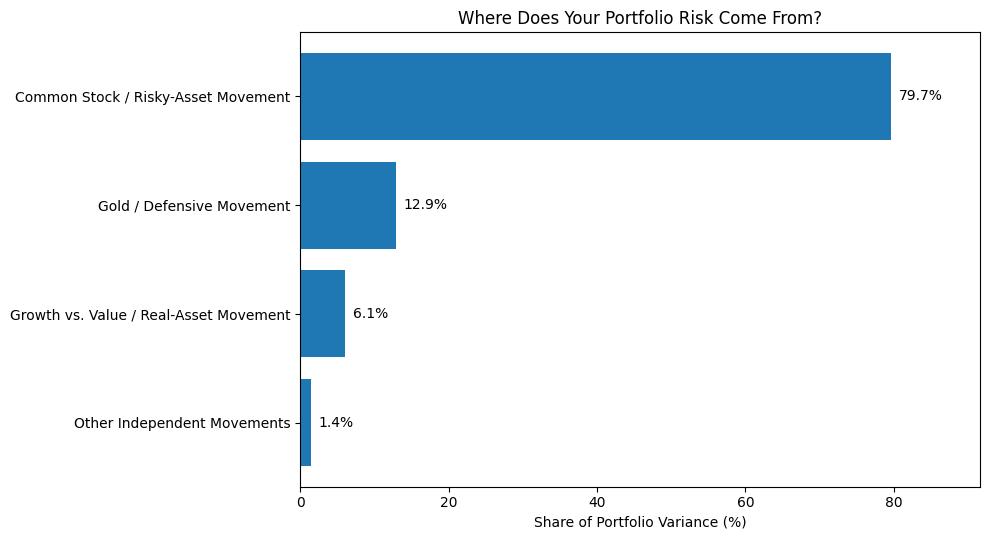

In [13]:
# ============================================================
# VISUAL PCA — WHERE DOES PORTFOLIO RISK COME FROM?
# ============================================================

import matplotlib.pyplot as plt

# First three PCs plus everything else
pc1_share = pc_risk_fraction[-1] * 100
pc2_share = pc_risk_fraction[-2] * 100
pc3_share = pc_risk_fraction[-3] * 100

other_share = 100 - (
    pc1_share
    + pc2_share
    + pc3_share
)

labels = [
    "Common Stock / Risky-Asset Movement",
    "Gold / Defensive Movement",
    "Growth vs. Value / Real-Asset Movement",
    "Other Independent Movements"
]

shares = [
    pc1_share,
    pc2_share,
    pc3_share,
    other_share
]

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

bars = ax.barh(
    labels,
    shares
)

ax.invert_yaxis()

ax.set_xlabel(
    "Share of Portfolio Variance (%)"
)

ax.set_title(
    "Where Does Your Portfolio Risk Come From?"
)

ax.set_xlim(
    0,
    max(shares) * 1.15
)

# Add percentage labels
for bar, value in zip(bars, shares):

    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# PCA — LOADINGS FOR PC4 THROUGH PC10
# ============================================================

for pc_number in range(4, 11):

    index = -pc_number

    eigenvalue = eigenvalues[index]
    eigenvector = eigenvectors[:, index]

    loadings = pd.Series(
        eigenvector,
        index=pca_returns.columns
    )

    table = pd.DataFrame({
        "Loading": loadings,
        "Absolute Loading": np.abs(loadings)
    })

    table = table.sort_values(
        "Absolute Loading",
        ascending=False
    )

    print("\n======================================")
    print(f" Principal Component {pc_number}")
    print("======================================")

    print(
        f"Explained Variance: "
        f"{explained_variance[index]:.2%}"
    )

    print("\nStrongest Asset Loadings")

    for asset, row in table.head(5).iterrows():
        print(
            f"{asset:25s} "
            f"{row['Loading']: .4f}"
        )


 Principal Component 4
Explained Variance: 4.46%

Strongest Asset Loadings
REITs                     -0.6230
Treasury Bonds            -0.4248
Value Stocks               0.3547
International Stocks       0.2927
Bonds                     -0.2762

 Principal Component 5
Explained Variance: 2.08%

Strongest Asset Loadings
International Stocks       0.7661
Treasury Bonds             0.3455
Gold                      -0.3270
Bonds                      0.2744
US Small Cap              -0.2380

 Principal Component 6
Explained Variance: 1.59%

Strongest Asset Loadings
US Small Cap              -0.7476
Value Stocks               0.3547
Treasury Bonds            -0.3099
REITs                      0.2927
S&P 500 Index Fund         0.2517

 Principal Component 7
Explained Variance: 1.05%

Strongest Asset Loadings
Value Stocks               0.5988
Treasury Bonds             0.4970
International Stocks      -0.3905
Bonds                      0.2871
REITs                     -0.2764

 Principal Comp

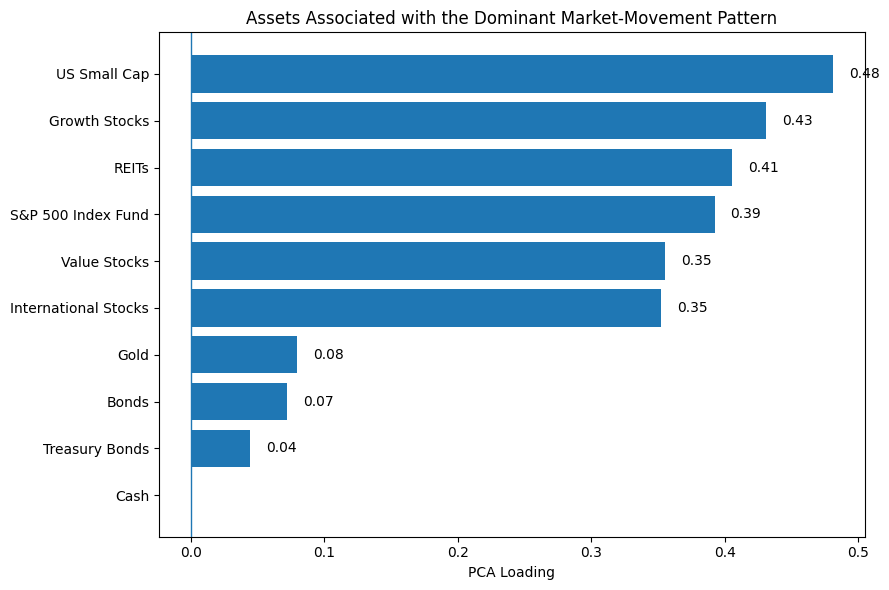

In [16]:
# ============================================================
# VISUAL PCA — ASSETS ASSOCIATED WITH PC1
# ============================================================

import matplotlib.pyplot as plt

# PC1 loadings
pc1_loadings = pd.Series(
    eigenvectors[:, -1],
    index=pca_returns.columns
)

# Flip sign only for visual consistency.
# Eigenvector direction itself is unchanged.
if pc1_loadings["S&P 500 Index Fund"] < 0:
    pc1_loadings = -pc1_loadings

# Sort from strongest to weakest absolute loading
pc1_plot = pc1_loadings.reindex(
    pc1_loadings.abs().sort_values(
        ascending=False
    ).index
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

bars = ax.barh(
    pc1_plot.index,
    pc1_plot.values
)

ax.invert_yaxis()

ax.axvline(
    0,
    linewidth=1
)

ax.set_xlabel(
    "PCA Loading"
)

ax.set_title(
    "Assets Associated with the Dominant Market-Movement Pattern"
)

# Add loading values
for bar, value in zip(
    bars,
    pc1_plot.values
):

    # Do not label values that are essentially zero
    if abs(value) < 0.01:
        continue

    offset = 0.012

    if value >= 0:
        x = value + offset
        ha = "left"
    else:
        x = value - offset
        ha = "right"

    ax.text(
        x,
        bar.get_y()
        + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha=ha
    )

plt.tight_layout()
plt.show()

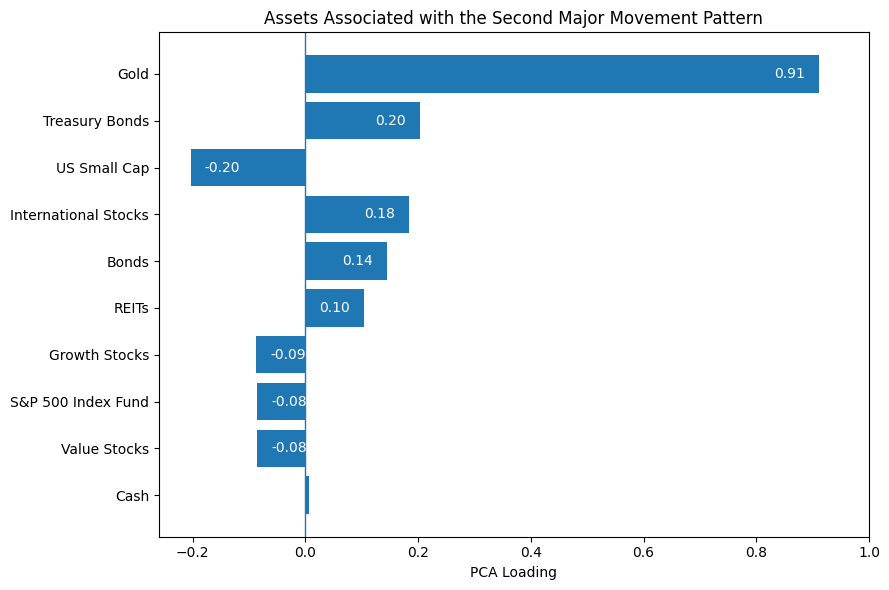

In [21]:
# ============================================================
# VISUAL PCA — ASSETS ASSOCIATED WITH PC2
# ============================================================

import matplotlib.pyplot as plt

pc2_loadings = pd.Series(
    eigenvectors[:, -2],
    index=pca_returns.columns
)

# Orient PC2 so Gold is positive for easier interpretation.
# The sign of an eigenvector is arbitrary.
if pc2_loadings["Gold"] < 0:
    pc2_loadings = -pc2_loadings

# Sort assets by absolute loading
pc2_plot = pc2_loadings.reindex(
    pc2_loadings.abs().sort_values(
        ascending=False
    ).index
)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 6)
)

bars = ax.barh(
    pc2_plot.index,
    pc2_plot.values
)

ax.invert_yaxis()

# Zero reference line
ax.axvline(
    0,
    linewidth=1
)

ax.set_xlabel(
    "PCA Loading"
)

ax.set_title(
    "Assets Associated with the Second Major Movement Pattern"
)

# Give both sides adequate plotting space
ax.set_xlim(
    -0.26,
    1.00
)

# ------------------------------------------------------------
# Add loading values
# ------------------------------------------------------------

for bar, value in zip(
    bars,
    pc2_plot.values
):

    # Do not label essentially zero values
    if abs(value) < 0.01:
        continue

    # Put labels inside larger bars
    if abs(value) >= 0.08:

        if value > 0:
            x = value - 0.025
            ha = "right"

        else:
            x = value + 0.025
            ha = "left"

        text_color = "white"

    # Very small bars: put label just outside
    else:

        if value > 0:
            x = value + 0.015
            ha = "left"

        else:
            x = value - 0.015
            ha = "right"

        text_color = "black"

    ax.text(
        x,
        bar.get_y()
        + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha=ha,
        color=text_color
    )

plt.tight_layout()
plt.show()

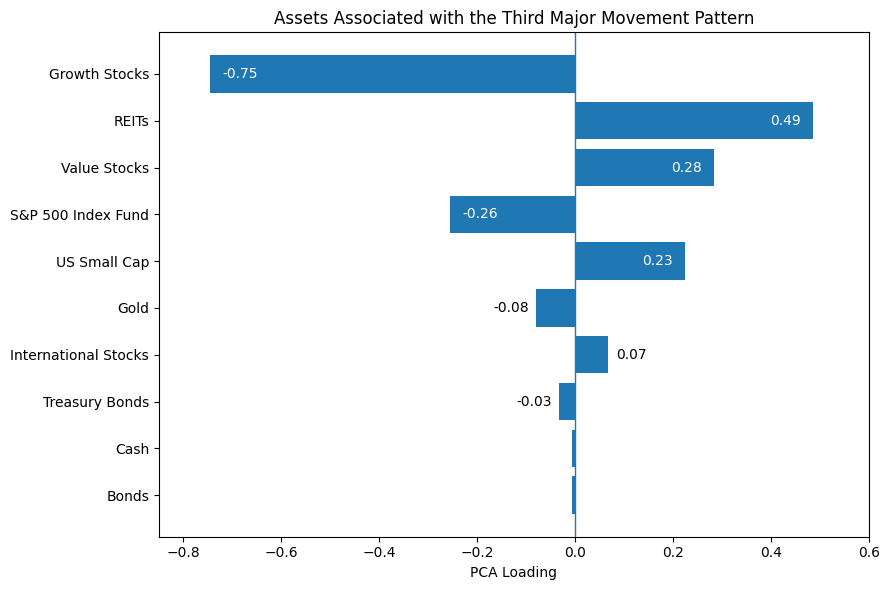

In [22]:
# ============================================================
# VISUAL PCA — ASSETS ASSOCIATED WITH PC3
# ============================================================

import matplotlib.pyplot as plt

pc3_loadings = pd.Series(
    eigenvectors[:, -3],
    index=pca_returns.columns
)

# Orient PC3 so REITs are positive for easier interpretation.
# The sign of an eigenvector is arbitrary.
if pc3_loadings["REITs"] < 0:
    pc3_loadings = -pc3_loadings

# Sort assets by absolute loading
pc3_plot = pc3_loadings.reindex(
    pc3_loadings.abs().sort_values(
        ascending=False
    ).index
)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 6)
)

bars = ax.barh(
    pc3_plot.index,
    pc3_plot.values
)

ax.invert_yaxis()

# Zero reference line
ax.axvline(
    0,
    linewidth=1
)

ax.set_xlabel(
    "PCA Loading"
)

ax.set_title(
    "Assets Associated with the Third Major Movement Pattern"
)

# Give both sides adequate plotting space
ax.set_xlim(
    -0.85,
    0.60
)

# ------------------------------------------------------------
# Add loading values
# ------------------------------------------------------------

for bar, value in zip(
    bars,
    pc3_plot.values
):

    # Do not label essentially zero values
    if abs(value) < 0.01:
        continue

    # Put labels inside larger bars
    if abs(value) >= 0.08:

        if value > 0:
            x = value - 0.025
            ha = "right"

        else:
            x = value + 0.025
            ha = "left"

        text_color = "white"

    # Very small bars: put label outside
    else:

        if value > 0:
            x = value + 0.015
            ha = "left"

        else:
            x = value - 0.015
            ha = "right"

        text_color = "black"

    ax.text(
        x,
        bar.get_y()
        + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha=ha,
        color=text_color
    )

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# VISUAL PCA — FINANCIAL WISDOM INTERPRETATION
# ============================================================

pc1_pct = pc_risk_fraction[-1] * 100
pc2_pct = pc_risk_fraction[-2] * 100
pc3_pct = pc_risk_fraction[-3] * 100

other_pct = 100 - (
    pc1_pct
    + pc2_pct
    + pc3_pct
)

top_three_pct = (
    pc1_pct
    + pc2_pct
    + pc3_pct
)

print("\n======================================")
print(" Hidden Risk Structure")
print("======================================")

print(
    f"\nDominant common market movement: "
    f"{pc1_pct:.1f}%"
)

print(
    f"Gold-related movement: "
    f"{pc2_pct:.1f}%"
)

print(
    f"Growth vs. value / real-asset movement: "
    f"{pc3_pct:.1f}%"
)

print(
    f"Other independent movements: "
    f"{other_pct:.1f}%"
)

print(
    f"\nThe first three movement patterns explain "
    f"{top_three_pct:.1f}%"
)

print(
    "of the historical variance in this portfolio."
)

print("\nWhat do I know?")

print(
    f"About {pc1_pct:.1f}% of this portfolio's "
    "historical variance"
)

print(
    "is associated with one dominant pattern of "
    "market movement."
)

print("\nWhat does it mean?")

print(
    "Several investments in the portfolio may have "
    "different names"
)

print(
    "but still respond to some of the same underlying "
    "market forces."
)

print(
    "The portfolio also contains investments that "
    "participate in"
)

print(
    "different movement patterns, which can contribute "
    "to diversification."
)

print("\nFinancial Wisdom:")

print(
    "Diversification is not simply owning more investments."
)

print(
    "It comes from combining investments that do not all "
    "behave"
)

print(
    "the same way under changing market conditions."
)

print(
    "\nHistorical relationships can change. "
    "PCA describes the data"
)

print(
    "we observed; it does not predict future market behavior."
)


 Hidden Risk Structure

Dominant common market movement: 79.7%
Gold-related movement: 12.9%
Growth vs. value / real-asset movement: 6.1%
Other independent movements: 1.4%

The first three movement patterns explain 98.6%
of the historical variance in this portfolio.

What do I know?
About 79.7% of this portfolio's historical variance
is associated with one dominant pattern of market movement.

What does it mean?
Several investments in the portfolio may have different names
but still respond to some of the same underlying market forces.
The portfolio also contains investments that participate in
different movement patterns, which can contribute to diversification.

Financial Wisdom:
Diversification is not simply owning more investments.
It comes from combining investments that do not all behave
the same way under changing market conditions.

Historical relationships can change. PCA describes the data
we observed; it does not predict future market behavior.


In [29]:
pca_analysis = analyze_portfolio_pca(
    test_weights,
    pca_returns,
    eigenvalues,
    eigenvectors
)

print("\n======================================")
print(" PCA Function Test")
print("======================================")

print(
    f"PC1 Variance Share: "
    f"{pca_analysis['risk_fraction'][-1]:.2%}"
)

print(
    f"PC2 Variance Share: "
    f"{pca_analysis['risk_fraction'][-2]:.2%}"
)

print(
    f"PC3 Variance Share: "
    f"{pca_analysis['risk_fraction'][-3]:.2%}"
)

print(
    f"Other Variance Share: "
    f"{np.sum(pca_analysis['risk_fraction'][:-3]):.2%}"
)

print(
    f"\nPCA Variance: "
    f"{pca_analysis['total_variance']:.8f}"
)

print(
    f"Direct Variance: "
    f"{pca_analysis['direct_variance']:.8f}"
)

difference = abs(
    pca_analysis["total_variance"]
    - pca_analysis["direct_variance"]
)

print(
    f"Difference: {difference:.12f}"
)

display_pca_wisdom(
    pca_analysis
)




 PCA Function Test
PC1 Variance Share: 79.67%
PC2 Variance Share: 12.87%
PC3 Variance Share: 6.08%
Other Variance Share: 1.38%

PCA Variance: 0.00116641
Direct Variance: 0.00116641
Difference: 0.000000000000

 Hidden Risk Structure

Dominant common market movement: 79.7%
Gold-related movement: 12.9%
Growth vs. value / real-asset movement: 6.1%
Other independent movements: 1.4%

The first three movement patterns explain 98.6%
of the historical variance in this portfolio.

What do I know?
About 79.7% of this portfolio's historical variance
is associated with one dominant pattern of market movement.

What does it mean?
Several investments may have different names
but still respond to some of the same underlying market forces.
Other investments participate in different movement patterns.
Those differences can help reduce dependence on a single source
of market movement.

Financial Wisdom:
Diversification is not simply owning more investments.
It comes from combining investments that do no

NameError: name 'portfolio' is not defined

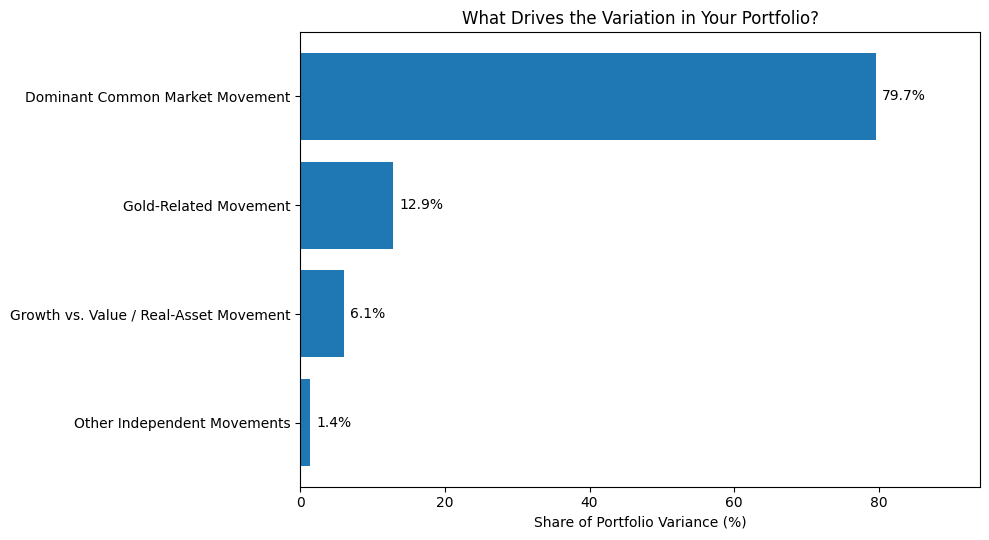

In [35]:
plot_pca_variance_structure(
    pca_analysis
)